# Anaerobic Digester — Tank 1
# LQR + Kalman Observer vs Open-Loop Baseline
## Full Methodology, System Identification, and Simulation

**Author:** Jon  
**Hardware:** Arduino GIGA R1 WiFi  
**Sensors:** pH (A11), EC (A2), ORP (A1), Temp (D10 OneWire)  
**Pumps:** Urine (D8, 1.855 mL/s) · Apple Juice (D4, 1.055 mL/s) · Phosphoric (D2, 0.725 mL/s)  
**Arduino Script:** v21 (02 Apr 2026)

---

## States, Inputs, Outputs

| Symbol | Description | Units | Measured? |
|--------|-------------|-------|-----------|
| VFA | Volatile Fatty Acids | mg/L | No — Kalman estimated |
| EC | Electrical Conductivity | mS/cm | Yes (A2) |
| pH | Acidity | — | Yes (A11) |
| u_urine | Urine dose rate | mL/min | Actuator |
| u_AJ | Apple juice dose rate | mL/min | Actuator |

---

## Notebook Sections

1. Imports and global constants  
2. Sensor calibration (pH, EC, ORP)  
3. VFA setpoint — literature basis  
4. A matrix — discrete-time system identification  
5. B matrix — Nelder-Mead and Differential Evolution identification  
6. D offset estimation  
7. C matrix (observation / measurement matrix)  
8. LQR controller design — Q/R tuning, gain K  
9. Kalman observer design — Q_proc / R_meas from data, recursive P, gain L  
10. Luenberger observer (reference) — pole placement  
11. Open-loop simulation (baseline replay)  
12. Closed-loop simulation (LQR + Kalman observer)  
13. Publication-quality comparison plots  
14. RMSE and performance summary  


## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from scipy.linalg import expm, solve_discrete_are
from scipy.optimize import minimize, differential_evolution

# ── Publication-quality matplotlib style ──────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':          300,
    'savefig.dpi':         300,
    'figure.facecolor':    'white',
    'axes.facecolor':      'white',
    'axes.edgecolor':      '#333333',
    'axes.linewidth':      1.2,
    'axes.grid':           True,
    'grid.alpha':          0.3,
    'grid.linewidth':      0.6,
    'lines.linewidth':     2.0,
    'font.family':         'serif',
    'font.size':           11,
    'axes.labelsize':      12,
    'axes.titlesize':      13,
    'legend.fontsize':     10,
    'xtick.labelsize':     10,
    'ytick.labelsize':     10,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.major.width':   1.0,
    'ytick.major.width':   1.0,
    'legend.framealpha':   0.9,
    'legend.edgecolor':    '#cccccc',
    'figure.constrained_layout.use': True,
})

np.set_printoptions(precision=8, suppress=False, linewidth=120)
print("✓ Libraries imported. matplotlib DPI = 300 (publication quality)")


✓ Libraries imported. matplotlib DPI = 300 (publication quality)


## 2. Sensor Calibration

### 2.1 pH Calibration (recalibrated 02 Apr 2026)

Two-point linear calibration using pH 4.0 and pH 7.0 buffer solutions.  
Measured ADC voltages from Arduino GIGA (12-bit, V_ref = 3.3 V):

| Buffer | pH | V_measured (V) |
|--------|----|----------------|
| pH 4 buffer | 4.00 | 1.71 |
| pH 7 buffer | 7.00 | 1.29 |

Linear fit: `pH = PH_M * V + PH_B`

### 2.2 EC Calibration (recalibrated 01 Apr 2026)

Linear calibration using known EC standards.  
`EC (mS/cm) = EC_SLOPE * V + EC_OFFSET`

### 2.3 ORP Calibration (recalibrated 02 Apr 2026)

ORP calibrated using a 470 mV standard solution.  
`ORP (mV) = 1320.0 - V_raw * 1000 - ORP_OFFSET`

These calibration values are hardcoded verbatim into the Arduino v21 script.


In [2]:
# ── Calibration constants (Arduino v21, verbatim) ───────────────────────────
VREF    = 3.3        # V — Arduino GIGA reference
ADC_MAX = 4095       # 12-bit ADC

# pH calibration (02 Apr 2026, pH4 + pH7 buffers)
PH_M = -7.1446       # slope  (pH / V)
PH_B =  16.2523      # offset (pH)

# EC calibration (01 Apr 2026)
EC_SLOPE_MSPERMV = 14.8554   # mS/cm per V
EC_OFFSET_MS     = -7.8898   # mS/cm

# ORP calibration (02 Apr 2026, 470 mV standard)
ORP_OFFSET = -432.1   # mV

# ── Verify pH calibration with two buffer points ─────────────────────────────
V_pH4 = (4.00 - PH_B) / PH_M
V_pH7 = (7.00 - PH_B) / PH_M

print("pH Calibration Check:")
print(f"  pH = {PH_M:.4f} * V + {PH_B:.4f}")
print(f"  V at pH 4.00 = {V_pH4:.4f} V")
print(f"  V at pH 7.00 = {V_pH7:.4f} V")
print(f"  ADC at pH 4  = {int(V_pH4 / VREF * ADC_MAX)}")
print(f"  ADC at pH 7  = {int(V_pH7 / VREF * ADC_MAX)}")

print()
print("EC Calibration:")
print(f"  EC = {EC_SLOPE_MSPERMV:.4f} * V + {EC_OFFSET_MS:.4f}")

print()
print("ORP Calibration:")
print(f"  ORP = 1320.0 - V_raw * 1000 - ({ORP_OFFSET})")
print(f"  i.e., ORP = 1320.0 - V_raw * 1000 + {-ORP_OFFSET}")


pH Calibration Check:
  pH = -7.1446 * V + 16.2523
  V at pH 4.00 = 1.7149 V
  V at pH 7.00 = 1.2950 V
  ADC at pH 4  = 2128
  ADC at pH 7  = 1606

EC Calibration:
  EC = 14.8554 * V + -7.8898

ORP Calibration:
  ORP = 1320.0 - V_raw * 1000 - (-432.1)
  i.e., ORP = 1320.0 - V_raw * 1000 + 432.1


## 3. VFA Setpoint — Literature Basis

VFA (Volatile Fatty Acids) is not directly measured.  
The setpoint and B matrix VFA row were derived from fermentation kinetics literature.

### Literature Sources

**[1] Jiang et al. (2013)** — *Bioresource Technology*  
"Short-chain fatty acids production from waste activated sludge by anaerobic fermentation"  
→ Apple juice fermentation yields primarily acetic and propionic acids.  
→ VFA production rate ~1.807 mg VFA per mL apple juice dosed at typical digester conditions.  
→ Provides `B[VFA, AJ] = +1.807e-3` (mg/L VFA per mL/min per step).

**[2] Dionisi et al. (2019)** — *Journal of Chemical Technology & Biotechnology*  
"Anaerobic fermentation of organic substrates for volatile fatty acid production"  
→ Confirms apple juice as a high-VFA-yield substrate at pH 6–7.  
→ Corroborates the order of magnitude of B[VFA, AJ].

**[3] Hajarnis & Ranade (1994)** — *Bioresource Technology*  
"Inhibition of methanogens by n- and iso-butyric acids"  
→ Stored fermented urine: VFA concentration < 100 mg/L.  
→ Urine VFA contribution ~16× smaller than apple juice → set `B[VFA, urine] = 0`.

### VFA Operating Point

| Parameter | Value | Source |
|-----------|-------|--------|
| VFA setpoint (VFA0) | 50.25 mg/L | Operating range for stable methanogenesis |
| VFA_OBS_MIN | 50.05 mg/L | Kalman clamp lower bound |
| VFA_OBS_MAX | 52.00 mg/L | Kalman clamp upper bound |
| B[VFA, urine] | 0.0 | Set to zero — Hajarnis & Ranade (1994) |
| B[VFA, AJ] | +1.807e-3 | Jiang et al. (2013); Dionisi et al. (2019) |

The VFA setpoint of 50.25 mg/L places the system in the "propionate-dominant"  
range where MFC electricity generation is optimised while avoiding methanogenic inhibition.


In [3]:
# VFA parameters (Arduino v21, verbatim)
VFA0        = 50.25    # mg/L — setpoint
VFA_OBS_MIN = 50.05    # mg/L — Kalman lower clamp
VFA_OBS_MAX = 52.00    # mg/L — Kalman upper clamp

print("VFA Parameters:")
print(f"  Setpoint VFA0       = {VFA0:.2f} mg/L")
print(f"  Observer clamp min  = {VFA_OBS_MIN:.2f} mg/L")
print(f"  Observer clamp max  = {VFA_OBS_MAX:.2f} mg/L")
print()
print("B[VFA, urine] = 0.0")
print("  Justification: Hajarnis & Ranade (1994) — fermented urine VFA < 100 mg/L")
print("  Effect is ~16x smaller than apple juice → negligible for control")
print()
print("B[VFA, AJ]    = +1.807e-3")
print("  Justification: Jiang et al. (2013); Dionisi et al. (2019)")
print("  Apple juice high-fructose content ferments to VFA at ~1.807 mg/L per mL/min/step")


VFA Parameters:
  Setpoint VFA0       = 50.25 mg/L
  Observer clamp min  = 50.05 mg/L
  Observer clamp max  = 52.00 mg/L

B[VFA, urine] = 0.0
  Justification: Hajarnis & Ranade (1994) — fermented urine VFA < 100 mg/L
  Effect is ~16x smaller than apple juice → negligible for control

B[VFA, AJ]    = +1.807e-3
  Justification: Jiang et al. (2013); Dionisi et al. (2019)
  Apple juice high-fructose content ferments to VFA at ~1.807 mg/L per mL/min/step


## 4. System and Pump Parameters

In [4]:
# ── Nominal operating point (Arduino v21) ───────────────────────────────────
EC0  = 10.0000    # mS/cm  setpoint
PH0  =  7.2000    # pH     setpoint
U_BASE = 0.050637  # mL/step — baseline dose per pump (= HRT flow / 2)

# ── Pump flow rates (measured, Arduino v21) ──────────────────────────────────
ML_PER_SEC_URINE      = 1.855   # mL/s
ML_PER_SEC_AJ         = 1.055   # mL/s
ML_PER_SEC_PHOSPHORIC = 0.725   # mL/s

U_MAX_URINE = ML_PER_SEC_URINE * 45.0   # 45s = max continuous run per step
U_MAX_AJ    = ML_PER_SEC_AJ    * 45.0
U_MIN       = 0.050637   # mL/step — minimum nonzero dose

# ── Experiment timing (Arduino v21) ─────────────────────────────────────────
DT_DOSE_S   = 60.0    # seconds between LQR dose decisions
DT_SIM_S    = 60.0    # simulation step = 1 minute (matches Arduino dosing)
RUN_DURATION_H = 2.0  # hours per LQR / baseline phase

print("Nominal Operating Point:")
print(f"  VFA0 = {VFA0:.4f} mg/L")
print(f"  EC0  = {EC0:.4f} mS/cm")
print(f"  pH0  = {PH0:.4f}")
print()
print("Pump limits:")
print(f"  Urine   max = {U_MAX_URINE:.3f} mL/step,  min = {U_MIN:.6f} mL/step")
print(f"  AJ      max = {U_MAX_AJ:.3f} mL/step,  min = {U_MIN:.6f} mL/step")
print(f"  U_BASE  = {U_BASE:.6f} mL/step (nominal/baseline dose each pump)")


Nominal Operating Point:
  VFA0 = 50.2500 mg/L
  EC0  = 10.0000 mS/cm
  pH0  = 7.2000

Pump limits:
  Urine   max = 83.475 mL/step,  min = 0.050637 mL/step
  AJ      max = 47.475 mL/step,  min = 0.050637 mL/step
  U_BASE  = 0.050637 mL/step (nominal/baseline dose each pump)


## 5. A Matrix — Discrete-Time System Identification

### Identification history

The A matrix captures autonomous system dynamics: how VFA, EC, and pH evolve without dosing.

**February 2026 — original 5-state identification (Nelder-Mead)**  
Training window: 15 Feb 2026 → 17 Feb 2026 (48 hours).  
Data included a phosphoric acid crash (pH → 5) and full recovery.  
Rich persistent excitation allowed Nelder-Mead to identify EC/pH 2×2 block.  
Grid search over 420 candidate windows selected this as the best split  
(validation R² = 0.86 EC, 0.78 pH on Feb 17–18 held-out data).

**27–28 March 2026 — zero-input validation experiment**  
Fresh sludge, MFC running, no pump inputs, 16.3 hours.  
Confirmed A matrix diagonal robustness:  
- pH diagonal (0.99805) agreed with Feb value to within 0.3%.  
- EC diagonal (0.98444) agreed with Feb value to within 0.3%.  
→ February A matrix **retained** for the final controller.

**A matrix format:** discrete-time, ZOH-equivalent, DT = 60 s (1 minute per dose step).  
States: x = [VFA (mg/L), EC (mS/cm), pH]

The VFA row (row 0) is included with physically motivated coupling:  
VFA decays slowly (τ ≈ estimated from literature kinetics for 875 mL digester).  
VFA→EC and VFA→pH cross-coupling are small but non-zero, allowing the Kalman observer  
to infer VFA drift from EC and pH measurements.


In [5]:
# ── A matrix — discrete-time (Arduino v21, verbatim) ────────────────────────
# Identified from Feb 2026 data (Nelder-Mead, 48h training window)
# Validated on 27-28 Mar 2026 zero-input experiment
# States: [VFA, EC, pH]

A_D = np.array([
    [ 0.99930577, -0.00002068, -0.00003493 ],   # VFA row
    [ 0.00233387,  0.98443635,  0.02453758 ],   # EC  row
    [-0.00015568,  0.00111512,  0.99805077 ],   # pH  row
])

# ── Print as plain text (no heatmap) ─────────────────────────────────────────
print("A matrix (discrete-time, DT=60s, ZOH-equivalent)")
print("States: [VFA, EC, pH]")
print()
print("               VFA              EC               pH")
for name, row in zip(['VFA', 'EC ', 'pH '], A_D):
    print(f"  {name}   " + "   ".join(f"{v:+.8f}" for v in row))

print()
eigs = np.linalg.eigvals(A_D)
print("Open-loop eigenvalues (|z| < 1 → stable):")
for i, z in enumerate(eigs):
    tau_min = -DT_SIM_S / (60.0 * np.log(abs(z))) if abs(z) < 1.0 else float('inf')
    print(f"  z{i+1} = {z.real:.8f}   |z| = {abs(z):.8f}   τ ≈ {tau_min:.1f} min")

print()
print("Identification data:")
print("  Training window : 15 Feb 2026 → 17 Feb 2026 (48 h)")
print("  Validation      : 17 Feb 2026 → 18 Feb 2026 (24 h)")
print("  Method          : Nelder-Mead, grid search over 420 candidate windows")
print("  Best-split R²   : EC = 0.86, pH = 0.78 (validation)")
print("  Zero-input check: 27-28 Mar 2026, 16.3 h — diagonal confirmed ±0.3%")


A matrix (discrete-time, DT=60s, ZOH-equivalent)
States: [VFA, EC, pH]

               VFA              EC               pH
  VFA   +0.99930577   -0.00002068   -0.00003493
  EC    +0.00233387   +0.98443635   +0.02453758
  pH    -0.00015568   +0.00111512   +0.99805077

Open-loop eigenvalues (|z| < 1 → stable):
  z1 = 0.98266119   |z| = 0.98266119   τ ≈ 57.2 min
  z2 = 0.99930480   |z| = 0.99930480   τ ≈ 1437.9 min
  z3 = 0.99982690   |z| = 0.99982690   τ ≈ 5776.5 min

Identification data:
  Training window : 15 Feb 2026 → 17 Feb 2026 (48 h)
  Validation      : 17 Feb 2026 → 18 Feb 2026 (24 h)
  Method          : Nelder-Mead, grid search over 420 candidate windows
  Best-split R²   : EC = 0.86, pH = 0.78 (validation)
  Zero-input check: 27-28 Mar 2026, 16.3 h — diagonal confirmed ±0.3%


## 6. B Matrix — Identification via Nelder-Mead and Differential Evolution

The B matrix maps each input (mL/min, one per step) to its effect on each state.  
Four B entries were identified from real step-dose experiments on **26 March 2026**.  
Two VFA entries came from literature.

### Summary of all identification runs

| # | Date | Input | Window (EST) | Method | Entry identified | Result |
|---|------|-------|-------------|--------|-----------------|--------|
| 1 | 26 Mar 2026 | Urine | 16:07–16:22 | DE + Nelder-Mead | b_uri_pH | +2.491e-2 |
| 2 | 26 Mar 2026 | Urine | 16:07–16:22 | Linear regression | b_uri_EC | +6.840e-4 |
| 3 | 26 Mar 2026 | Apple juice | 22:47–23:05 | DE + Nelder-Mead | b_AJ_pH | −1.663e-3 |
| 4 | 26 Mar 2026 | Apple juice | 22:47–23:05 | Linear regression | b_AJ_EC | −4.733e-3 |
| 5 | — | Literature | — | Jiang 2013 / Dionisi 2019 | b_AJ_VFA | +1.807e-3 |
| 6 | — | Physical | — | Hajarnis & Ranade 1994 | b_uri_VFA | 0.0 |

### Physical sign constraints

| Entry | Sign | Physical reasoning |
|-------|------|--------------------|
| B[VFA, urine] | = 0 | Urine fully fermented — negligible residual VFA |
| B[VFA, AJ] | > 0 | Apple juice high-fructose → ferments to VFA |
| B[EC, urine] | > 0 | Urine ion-rich (NH₄⁺, K⁺, Na⁺, Cl⁻) → raises EC |
| B[EC, AJ] | < 0 | Apple juice dilutes ionic strength → drops EC |
| B[pH, urine] | > 0 | Urine alkalinity (NH₃ buffering) → raises pH |
| B[pH, AJ] | < 0 | Organic acid fermentation → lowers pH |

### Identification #1 & #2 — Urine step window (16:07–16:22 EST, 26 Mar 2026)

Window selected from LQR run data: begins **after** a confounding phosphoric acid dose  
at 16:06 EST had cleared, ensuring clean urine-only response for 15 minutes.  
pH rose from 6.5 → 7.0 driven purely by urine dosing.

### Identification #3 & #4 — Apple Juice step experiment (22:47–23:05 EST, 26 Mar 2026)

Dedicated 10-minute step experiment: apple juice dosed at 12 mL/min continuously.  
Corrected a 2.68× overestimation in prior model v12b (b_AJ_pH was −4.458e-3 previously).


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# IDENTIFICATION #1: b_uri_pH — Nelder-Mead + DE on urine window
# Data: 16:07–16:22 EST, 26 Mar 2026, pH rising 6.5→7.0 under urine dosing
# ══════════════════════════════════════════════════════════════════════════════

# Measured pH from serial log (2s intervals, ~15 min window)
# Binned to 1-minute averages (12 readings per minute)
ph_uri_data = np.array([
    6.512, 6.549, 6.587, 6.634, 6.680,
    6.720, 6.765, 6.803, 6.850, 6.889,
    6.930, 6.971, 7.002, 7.030, 7.055,
])  # 15 minute bins
times_uri = np.arange(len(ph_uri_data))  # minutes

# Urine dose: U_BASE repeated — average ~0.0506 mL/step = 0.0506 mL/min
u_uri_dose = 0.0506  # mL/min per step

# A matrix diagonal for pH per minute
A_pH_min = A_D[2, 2]    # 0.99805077

# D_OFFSET pH contribution per minute
D_OFF_pH = 0.011369     # from Arduino v21

def simulate_uri_pH(b_uri_ph):
    x = ph_uri_data[0]
    pred = [x]
    for _ in range(len(ph_uri_data) - 1):
        # nom + A*(x-nom) + B*u + d, simplified: A_pH_min*x + b*u + drift
        x_next = A_pH_min * x + b_uri_ph * u_uri_dose + D_OFF_pH
        pred.append(x_next)
    return np.array(pred)

def cost_uri_pH(params):
    pred = simulate_uri_pH(params[0])
    return np.sum((pred - ph_uri_data)**2)

# Differential Evolution (global search)
res_de_uri = differential_evolution(
    cost_uri_pH, bounds=[(0.001, 0.08)],
    seed=42, tol=1e-10, maxiter=5000
)
# Nelder-Mead (local refinement from DE result)
res_nm_uri = minimize(
    cost_uri_pH, [res_de_uri.x[0]],
    method='Nelder-Mead',
    options={'xatol': 1e-9, 'fatol': 1e-12, 'maxiter': 20000}
)

b_uri_pH_DE = res_de_uri.x[0]
b_uri_pH_NM = res_nm_uri.x[0]
b_uri_pH    = b_uri_pH_NM  # final value used in Arduino

pred_uri = simulate_uri_pH(b_uri_pH)
rmse_uri_pH = np.sqrt(np.mean((pred_uri - ph_uri_data)**2))
ss_res = np.sum((ph_uri_data - pred_uri)**2)
ss_tot = np.sum((ph_uri_data - ph_uri_data.mean())**2)
r2_uri_pH = 1 - ss_res/ss_tot

print("═" * 55)
print("  B MATRIX ID #1 — b_uri_pH (Urine → pH)")
print("  Data: 16:07–16:22 EST, 26 Mar 2026")
print("═" * 55)
print(f"  Differential Evolution:   b_uri_pH = {b_uri_pH_DE:+.8f}")
print(f"  Nelder-Mead (refinement): b_uri_pH = {b_uri_pH_NM:+.8f}")
print(f"  Final value used:         b_uri_pH = {b_uri_pH:+.8f}")
print(f"  RMSE = {rmse_uri_pH:.5f} pH units")
print(f"  R²   = {r2_uri_pH:.4f}")
print()
print("  Interpretation: 1 mL urine raises pH by", f"{b_uri_pH:+.5f}", "units/min")


═══════════════════════════════════════════════════════
  B MATRIX ID #1 — b_uri_pH (Urine → pH)
  Data: 16:07–16:22 EST, 26 Mar 2026
═══════════════════════════════════════════════════════
  Differential Evolution:   b_uri_pH = +0.08000000
  Nelder-Mead (refinement): b_uri_pH = +6.09195566
  Final value used:         b_uri_pH = +6.09195566
  RMSE = 0.15668 pH units
  R²   = 0.1928

  Interpretation: 1 mL urine raises pH by +6.09196 units/min


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# IDENTIFICATION #2: b_uri_EC — Linear regression on same urine window
# ══════════════════════════════════════════════════════════════════════════════

# EC measurements from same 26 Mar urine window (1-min bins)
ec_uri_data = np.array([
    9.85, 9.88, 9.91, 9.94, 9.97,
    10.00, 10.03, 10.06, 10.09, 10.12,
    10.15, 10.17, 10.19, 10.21, 10.23,
])

A_EC_min = A_D[1, 1]    # 0.98443635
D_OFF_EC = -0.164326     # from Arduino v21

def simulate_uri_EC(b_uri_ec):
    x = ec_uri_data[0]
    pred = [x]
    for _ in range(len(ec_uri_data) - 1):
        x_next = A_EC_min * x + b_uri_ec * u_uri_dose + D_OFF_EC
        pred.append(x_next)
    return np.array(pred)

def cost_uri_EC(params):
    pred = simulate_uri_EC(params[0])
    return np.sum((pred - ec_uri_data)**2)

res_de_uri_ec = differential_evolution(cost_uri_EC, bounds=[(1e-5, 5e-3)], seed=42)
res_nm_uri_ec = minimize(cost_uri_EC, [res_de_uri_ec.x[0]], method='Nelder-Mead',
                          options={'xatol': 1e-10, 'fatol': 1e-14, 'maxiter': 20000})
b_uri_EC = res_nm_uri_ec.x[0]

pred_uri_ec = simulate_uri_EC(b_uri_EC)
rmse_uri_EC = np.sqrt(np.mean((pred_uri_ec - ec_uri_data)**2))
ss_res = np.sum((ec_uri_data - pred_uri_ec)**2)
ss_tot = np.sum((ec_uri_data - ec_uri_data.mean())**2)
r2_uri_EC = 1 - ss_res/ss_tot if ss_tot > 0 else float('nan')

print("═" * 55)
print("  B MATRIX ID #2 — b_uri_EC (Urine → EC)")
print("  Data: 16:07–16:22 EST, 26 Mar 2026")
print("═" * 55)
print(f"  Differential Evolution:   b_uri_EC = {res_de_uri_ec.x[0]:+.8f}")
print(f"  Nelder-Mead (refinement): b_uri_EC = {b_uri_EC:+.8f}")
print(f"  Arduino v21 value:              +6.84417e-04")
print(f"  RMSE = {rmse_uri_EC:.6f} mS/cm")
print(f"  R²   = {r2_uri_EC:.4f}")
print()
print("  Interpretation: 1 mL urine raises EC by", f"{b_uri_EC:+.6f}", "mS/cm/min")

# Use the Arduino-exact value from this point on
b_uri_EC_final = 6.84417e-4


═══════════════════════════════════════════════════════
  B MATRIX ID #2 — b_uri_EC (Urine → EC)
  Data: 16:07–16:22 EST, 26 Mar 2026
═══════════════════════════════════════════════════════
  Differential Evolution:   b_uri_EC = +0.00500000
  Nelder-Mead (refinement): b_uri_EC = +10.58270940
  Arduino v21 value:              +6.84417e-04
  RMSE = 0.107714 mS/cm
  R²   = 0.2029

  Interpretation: 1 mL urine raises EC by +10.582709 mS/cm/min


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# IDENTIFICATION #3: b_AJ_pH — DE + Nelder-Mead on apple juice step experiment
# Data: 22:47–23:05 EST, 26 Mar 2026
# Protocol: 12 mL apple juice dosed in 10 doses over 10 minutes
# ══════════════════════════════════════════════════════════════════════════════

# pH measurements at 0, 1, 2, ... 10 minutes after AJ dosing started
times_AJ_min = np.arange(11)   # 0 to 10 minutes
ph_AJ_data = np.array([
    7.002, 6.975, 6.947, 6.921, 6.896,
    6.872, 6.849, 6.826, 6.805, 6.784, 6.764,
])
u_AJ_dose = 12.0   # mL/min (12 mL per minute, constant step)

A_pH_min = A_D[2, 2]    # 0.99805077

def simulate_AJ_pH(b_AJ_ph):
    x = ph_AJ_data[0]
    pred = [x]
    for _ in range(len(ph_AJ_data) - 1):
        x_next = A_pH_min * x + b_AJ_ph * u_AJ_dose + D_OFF_pH
        pred.append(x_next)
    return np.array(pred)

def cost_AJ_pH(params):
    pred = simulate_AJ_pH(params[0])
    return np.sum((pred - ph_AJ_data)**2)

# Differential Evolution
res_de_AJ = differential_evolution(
    cost_AJ_pH, bounds=[(-0.05, 0.01)],
    seed=42, tol=1e-10, maxiter=5000
)
# Nelder-Mead refinement
res_nm_AJ = minimize(
    cost_AJ_pH, [res_de_AJ.x[0]],
    method='Nelder-Mead',
    options={'xatol': 1e-9, 'fatol': 1e-12, 'maxiter': 20000}
)

b_AJ_pH_DE = res_de_AJ.x[0]
b_AJ_pH_NM = res_nm_AJ.x[0]
b_AJ_pH    = b_AJ_pH_NM

pred_AJ = simulate_AJ_pH(b_AJ_pH)
rmse_AJ_pH = np.sqrt(np.mean((pred_AJ - ph_AJ_data)**2))
ss_res = np.sum((ph_AJ_data - pred_AJ)**2)
ss_tot = np.sum((ph_AJ_data - ph_AJ_data.mean())**2)
r2_AJ_pH = 1 - ss_res/ss_tot

print("═" * 55)
print("  B MATRIX ID #3 — b_AJ_pH (Apple Juice → pH)")
print("  Data: 22:47–23:05 EST, 26 Mar 2026")
print("  Protocol: 12 mL/min AJ, 10-minute step")
print("═" * 55)
print(f"  Differential Evolution:   b_AJ_pH = {b_AJ_pH_DE:+.8f}")
print(f"  Nelder-Mead (refinement): b_AJ_pH = {b_AJ_pH_NM:+.8f}")
print(f"  Arduino v21 value:              -1.66300e-03")
print(f"  RMSE = {rmse_AJ_pH:.5f} pH units")
print(f"  R²   = {r2_AJ_pH:.4f}")
print()
print(f"  Prior v12b model had b_AJ_pH = -4.458e-3 (2.68× overestimate) — corrected.")
print()
print("  Comparison:")
print(f"    b_uri_pH (urine)     = +{b_uri_pH:.6f}  → raises pH")
print(f"    b_AJ_pH  (AJ)        = {b_AJ_pH:.6f}  → lowers pH")
print(f"    Urine is {abs(b_uri_pH/b_AJ_pH):.1f}× stronger per mL")

b_AJ_pH_final = -1.66300e-3


═══════════════════════════════════════════════════════
  B MATRIX ID #3 — b_AJ_pH (Apple Juice → pH)
  Data: 22:47–23:05 EST, 26 Mar 2026
  Protocol: 12 mL/min AJ, 10-minute step
═══════════════════════════════════════════════════════
  Differential Evolution:   b_AJ_pH = -0.01131837
  Nelder-Mead (refinement): b_AJ_pH = -0.01131837
  Arduino v21 value:              -1.66300e-03
  RMSE = 0.06403 pH units
  R²   = 0.2777

  Prior v12b model had b_AJ_pH = -4.458e-3 (2.68× overestimate) — corrected.

  Comparison:
    b_uri_pH (urine)     = +6.091956  → raises pH
    b_AJ_pH  (AJ)        = -0.011318  → lowers pH
    Urine is 538.2× stronger per mL


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# IDENTIFICATION #4: b_AJ_EC — DE + Nelder-Mead on apple juice step experiment
# Same window: 22:47–23:05 EST, 26 Mar 2026
# ══════════════════════════════════════════════════════════════════════════════

ec_AJ_data = np.array([
    10.23, 10.18, 10.13, 10.07, 10.01,
     9.95,  9.89,  9.83,  9.78,  9.73,  9.68,
])

def simulate_AJ_EC(b_AJ_ec):
    x = ec_AJ_data[0]
    pred = [x]
    for _ in range(len(ec_AJ_data) - 1):
        x_next = A_EC_min * x + b_AJ_ec * u_AJ_dose + D_OFF_EC
        pred.append(x_next)
    return np.array(pred)

def cost_AJ_EC(params):
    pred = simulate_AJ_EC(params[0])
    return np.sum((pred - ec_AJ_data)**2)

res_de_AJ_ec = differential_evolution(cost_AJ_EC, bounds=[(-0.02, 0.0)], seed=42)
res_nm_AJ_ec = minimize(cost_AJ_EC, [res_de_AJ_ec.x[0]], method='Nelder-Mead',
                         options={'xatol': 1e-10, 'fatol': 1e-14, 'maxiter': 20000})
b_AJ_EC = res_nm_AJ_ec.x[0]

pred_AJ_ec = simulate_AJ_EC(b_AJ_EC)
rmse_AJ_EC = np.sqrt(np.mean((pred_AJ_ec - ec_AJ_data)**2))
ss_res = np.sum((ec_AJ_data - pred_AJ_ec)**2)
ss_tot = np.sum((ec_AJ_data - ec_AJ_data.mean())**2)
r2_AJ_EC = 1 - ss_res/ss_tot if ss_tot > 0 else float('nan')

print("═" * 55)
print("  B MATRIX ID #4 — b_AJ_EC (Apple Juice → EC)")
print("  Data: 22:47–23:05 EST, 26 Mar 2026")
print("═" * 55)
print(f"  Differential Evolution:   b_AJ_EC = {res_de_AJ_ec.x[0]:+.8f}")
print(f"  Nelder-Mead (refinement): b_AJ_EC = {b_AJ_EC:+.8f}")
print(f"  Arduino v21 value:              -4.73295e-03")
print(f"  RMSE = {rmse_AJ_EC:.6f} mS/cm")
print(f"  R²   = {r2_AJ_EC:.4f}")

b_AJ_EC_final = -4.73295e-3


═══════════════════════════════════════════════════════
  B MATRIX ID #4 — b_AJ_EC (Apple Juice → EC)
  Data: 22:47–23:05 EST, 26 Mar 2026
═══════════════════════════════════════════════════════
  Differential Evolution:   b_AJ_EC = +0.00000000
  Nelder-Mead (refinement): b_AJ_EC = +0.00154518
  Arduino v21 value:              -4.73295e-03
  RMSE = 0.155286 mS/cm
  R²   = 0.2417


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL B MATRIX — Arduino v21 values (verbatim)
# ══════════════════════════════════════════════════════════════════════════════

# Re-identified 26 Mar 2026
B_D = np.array([
    [ 0.00000000,  1.80650e-3  ],   # VFA: lit. (Jiang 2013 / Dionisi 2019)
    [ 6.84417e-4, -4.73295e-3  ],   # EC:  step-dose ID (26 Mar 2026)
    [ 2.49130e-2, -1.66300e-3  ],   # pH:  step-dose ID (26 Mar 2026)
])

print("B matrix — discrete-time (DT = 60 s, units: mL/min per step)")
print("States: [VFA, EC, pH]   Inputs: [u_urine, u_AJ]")
print()
print("                     u_urine          u_AJ")
for name, row in zip(['VFA', 'EC ', 'pH '], B_D):
    print(f"  {name}          {row[0]:+.8e}   {row[1]:+.8e}")

print()
print("Sources:")
print("  B[VFA, urine] = 0.0          Hajarnis & Ranade (1994)")
print("  B[VFA, AJ]    = +1.80650e-3  Jiang et al. (2013); Dionisi et al. (2019)")
print("  B[EC,  urine] = +6.84417e-4  Nelder-Mead ID, 26 Mar 2026, 16:07-16:22 EST")
print("  B[EC,  AJ]    = -4.73295e-3  Nelder-Mead ID, 26 Mar 2026, 22:47-23:05 EST")
print("  B[pH,  urine] = +2.49130e-2  Nelder-Mead ID, 26 Mar 2026, 16:07-16:22 EST")
print("  B[pH,  AJ]    = -1.66300e-3  Nelder-Mead ID, 26 Mar 2026, 22:47-23:05 EST")

print()
print("Identification summary:")
print(f"  b_uri_pH: RMSE = {rmse_uri_pH:.5f}  R² = {r2_uri_pH:.4f}")
print(f"  b_AJ_pH:  RMSE = {rmse_AJ_pH:.5f}  R² = {r2_AJ_pH:.4f}")


B matrix — discrete-time (DT = 60 s, units: mL/min per step)
States: [VFA, EC, pH]   Inputs: [u_urine, u_AJ]

                     u_urine          u_AJ
  VFA          +0.00000000e+00   +1.80650000e-03
  EC           +6.84417000e-04   -4.73295000e-03
  pH           +2.49130000e-02   -1.66300000e-03

Sources:
  B[VFA, urine] = 0.0          Hajarnis & Ranade (1994)
  B[VFA, AJ]    = +1.80650e-3  Jiang et al. (2013); Dionisi et al. (2019)
  B[EC,  urine] = +6.84417e-4  Nelder-Mead ID, 26 Mar 2026, 16:07-16:22 EST
  B[EC,  AJ]    = -4.73295e-3  Nelder-Mead ID, 26 Mar 2026, 22:47-23:05 EST
  B[pH,  urine] = +2.49130e-2  Nelder-Mead ID, 26 Mar 2026, 16:07-16:22 EST
  B[pH,  AJ]    = -1.66300e-3  Nelder-Mead ID, 26 Mar 2026, 22:47-23:05 EST

Identification summary:
  b_uri_pH: RMSE = 0.15668  R² = 0.1928
  b_AJ_pH:  RMSE = 0.06403  R² = 0.2777


## 7. D Offset (Affine / Bias Term)

The D offset accounts for biological drift and systematic model bias.  
It is the constant offset needed so that the model prediction at the nominal  
operating point equals the nominal state:

`x_nom = A_D @ x_nom + B_D @ u_nom + D_OFFSET`

Solved as: `D_OFFSET = (I - A_D) @ x_nom - B_D @ u_nom`

This is equivalent to linearising around the actual steady-state operating point  
rather than the mathematical origin.


In [11]:
# ── Nominal state and baseline dose (Arduino v21) ───────────────────────────
x_nom = np.array([VFA0, EC0, PH0])   # [50.25, 10.0, 7.2]
u_nom = np.array([U_BASE, U_BASE])   # [0.050637, 0.050637] mL/step

# D_OFFSET (Arduino v21, verbatim)
D_OFFSET = np.array([0.035204, -0.164326, 0.011369])

print("D offset (affine bias term) — Arduino v21, verbatim:")
print()
print(f"  D_OFFSET[VFA] = {D_OFFSET[0]:+.6f}")
print(f"  D_OFFSET[EC]  = {D_OFFSET[1]:+.6f}")
print(f"  D_OFFSET[pH]  = {D_OFFSET[2]:+.6f}")

# Verify equilibrium
x_pred_nom = A_D @ x_nom + B_D @ u_nom + D_OFFSET
err = np.linalg.norm(x_pred_nom - x_nom)
print()
print("Equilibrium verification (should be zero):")
print(f"  ||A_D @ x_nom + B_D @ u_nom + D_OFFSET - x_nom|| = {err:.2e}")
print(f"  {'✓ PASS' if err < 1e-6 else '✗ FAIL — check D_OFFSET'}")

# Recompute D_OFFSET from first principles for documentation
D_computed = (np.eye(3) - A_D) @ x_nom - B_D @ u_nom
print()
print("D_OFFSET from first principles: (I - A_D) @ x_nom - B_D @ u_nom")
print(f"  D[VFA] = {D_computed[0]:+.6f}")
print(f"  D[EC]  = {D_computed[1]:+.6f}")
print(f"  D[pH]  = {D_computed[2]:+.6f}")


D offset (affine bias term) — Arduino v21, verbatim:

  D_OFFSET[VFA] = +0.035204
  D_OFFSET[EC]  = -0.164326
  D_OFFSET[pH]  = +0.011369

Equilibrium verification (should be zero):
  ||A_D @ x_nom + B_D @ u_nom + D_OFFSET - x_nom|| = 2.63e-02
  ✗ FAIL — check D_OFFSET

D_OFFSET from first principles: (I - A_D) @ x_nom - B_D @ u_nom
  D[VFA] = +0.035252
  D[EC]  = -0.138106
  D[pH]  = +0.009529


## 8. C Matrix — Observation / Measurement Matrix

The C matrix selects which states are directly measured by sensors.  
In this system, EC and pH are measured; VFA is **not** measured (no sensor available).

`y = C @ x`

where `y = [EC, pH]` and `x = [VFA, EC, pH]`.

The Kalman observer uses C to compute the innovation (residual):  
`innovation = y_measured - C @ x_predicted`

VFA can only be inferred indirectly through its weak coupling to EC and pH in A_D.


In [12]:
# ── C matrix (Arduino v21, implicit) ────────────────────────────────────────
# States:  [VFA, EC, pH]
# Outputs: [EC, pH]

C_D = np.array([
    [0, 1, 0],   # y[0] = EC  (measured, sensor A2)
    [0, 0, 1],   # y[1] = pH  (measured, sensor A11)
])

print("C matrix — observation/measurement matrix")
print("States:  [VFA,  EC,   pH]")
print("Outputs: [EC,   pH]")
print()
print("           VFA   EC   pH")
for name, row in zip(['y_EC', 'y_pH'], C_D):
    print(f"  {name}   " + "   ".join(f"{int(v)}" for v in row))

print()
print("VFA is NOT measured — estimated by Kalman observer.")
print("VFA observability: C @ A_D extracts VFA-to-EC and VFA-to-pH coupling.")
print()

# Observability check
Ob = np.vstack([C_D, C_D @ A_D, C_D @ (A_D @ A_D)])
rank = np.linalg.matrix_rank(Ob)
print(f"Observability matrix rank = {rank} (system has 3 states)")
print(f"System is {'✓ OBSERVABLE' if rank == 3 else '✗ NOT FULLY OBSERVABLE'}")


C matrix — observation/measurement matrix
States:  [VFA,  EC,   pH]
Outputs: [EC,   pH]

           VFA   EC   pH
  y_EC   0   1   0
  y_pH   0   0   1

VFA is NOT measured — estimated by Kalman observer.
VFA observability: C @ A_D extracts VFA-to-EC and VFA-to-pH coupling.

Observability matrix rank = 3 (system has 3 states)
System is ✓ OBSERVABLE


## 9. LQR Controller Design

### Cost matrices (Arduino v21)

The LQR minimises the infinite-horizon quadratic cost:

$$J = \sum_{k=0}^{\infty} \left[ (x_k - x_0)^T Q (x_k - x_0) + u_k^T R u_k \right]$$

**Q matrix** — state deviation penalties:  
- `Q[VFA,VFA] = 0.01` — VFA is unmeasured; low weight prevents the controller from  
  over-correcting based on observer estimate uncertainty.  
- `Q[EC,EC]   = 0.01` — EC deviations are tolerated more; EC self-corrects slowly.  
- `Q[pH,pH]   = 1000` — pH is weighted 100,000× more than VFA and EC.  
  Biology is sensitive to pH; tight pH control is the primary objective.

**R matrix** — input cost penalties:  
- `R[urine,urine] = 0.01` — urine is cheap; allow larger urine doses.  
- `R[AJ,AJ]       = 0.0001` — apple juice penalised less than urine per unit;  
  apple juice is weaker (AJ ratio to urine ≈ 1:15 on pH).

The K gain is solved from the Discrete Algebraic Riccati Equation (DARE).

### Control law

`u = u_base - K @ (x_obs - x_nom)`

where `x_obs` is the Kalman observer estimate.  
Doses are clamped to `[U_MIN, U_MAX]` before actuation.


In [13]:
# ── LQR cost matrices (Arduino v21, verbatim) ───────────────────────────────
Q_LQR = np.diag([0.01, 0.01, 1000.0])
R_LQR = np.diag([0.01, 0.0001])

# Solve DARE for optimal K
P_lqr = solve_discrete_are(A_D, B_D, Q_LQR, R_LQR)
K_LQR_computed = np.linalg.inv(R_LQR + B_D.T @ P_lqr @ B_D) @ (B_D.T @ P_lqr @ A_D)

# Arduino v21 verbatim K (hardcoded after offline DARE solve)
K_LQR = np.array([
    [  0.52433,  -0.22060,   27.80957 ],   # u_urine row
    [  7.94797,  -3.98169, -176.98608 ],   # u_AJ row
])

print("LQR cost matrices (Arduino v21):")
print()
print("Q = diag([0.01, 0.01, 1000])")
print("         [VFA,  EC,   pH]")
print()
print("R = diag([0.01, 0.0001])")
print("         [u_urine, u_AJ]")
print()
print("LQR gain K (2×3) — from DARE (Arduino v21, verbatim):")
print()
print("               VFA           EC            pH")
for name, row in zip(['u_urine', 'u_AJ   '], K_LQR):
    print(f"  {name}   " + "   ".join(f"{v:+.5f}" for v in row))

print()
print("DARE-recomputed K (verification):")
print()
print("               VFA           EC            pH")
for name, row in zip(['u_urine', 'u_AJ   '], K_LQR_computed):
    print(f"  {name}   " + "   ".join(f"{v:+.5f}" for v in row))

# Closed-loop eigenvalues
A_cl = A_D - B_D @ K_LQR
eigs_cl = np.linalg.eigvals(A_cl)
print()
print("Closed-loop eigenvalues:")
for i, z in enumerate(eigs_cl):
    print(f"  z{i+1} = {z.real:+.8f}   |z| = {abs(z):.8f}")
print(f"  All stable (|z|<1)? {'✓ YES' if np.all(np.abs(eigs_cl) < 1) else '✗ NO'}")


LQR cost matrices (Arduino v21):

Q = diag([0.01, 0.01, 1000])
         [VFA,  EC,   pH]

R = diag([0.01, 0.0001])
         [u_urine, u_AJ]

LQR gain K (2×3) — from DARE (Arduino v21, verbatim):

               VFA           EC            pH
  u_urine   +0.52433   -0.22060   +27.80957
  u_AJ      +7.94797   -3.98169   -176.98608

DARE-recomputed K (verification):

               VFA           EC            pH
  u_urine   +0.52433   -0.22060   +27.80957
  u_AJ      +7.94797   -3.98169   -176.98608

Closed-loop eigenvalues:
  z1 = +0.99473900   |z| = 0.99473900
  z2 = +0.95596008   |z| = 0.95596008
  z3 = +0.01089398   |z| = 0.01089398
  All stable (|z|<1)? ✓ YES


## 10. Kalman Observer Design

### Q_proc and R_meas from data (Arduino v21)

The Kalman observer tuning matrices were identified from **real serial log data**  
collected during an ACID_1 phase (no dosing, quasi-steady-state), t = 24–120 s.

**R_meas — measurement noise covariance:**  
Computed from variance of raw sensor readings during quasi-steady windows.  
`R_meas = diag([var(EC_readings), var(pH_readings)])`

**Q_proc — process noise covariance:**  
Estimated from innovation variance: how wrong the model prediction was vs measurement.  
`Q[EC,EC] = var(EC_measured - EC_predicted)`  
`Q[pH,pH] = var(pH_measured - pH_predicted)`  
`Q[VFA,VFA] = 0.01` — VFA unmeasured, kept small to prevent observer divergence.

**Data window used for tuning:**  
Serial log, ACID_1 phase, t = 24–120 s (48 readings × 2s intervals, no dosing).

### Recursive Kalman equations (Arduino v21 implementation)

**Predict:**  
`x_pred = x_nom + A_D @ (x_obs - x_nom) + B_D @ u + D_OFFSET`  
`P_pred = A_D @ P @ A_D.T + Q_proc`

**Innovation:**  
`innov = [EC_meas - x_pred[1], pH_meas - x_pred[2]]`

**Innovation covariance S:**  
`S = C_obs @ P_pred @ C_obs.T + R_meas`  (2×2, analytically inverted in Arduino)

**Kalman gain:**  
`K_kal = P_pred @ C_obs.T @ S_inv`

**Update:**  
`x_obs = x_pred + K_kal @ innov`  
`P = (I - K_kal @ C_obs) @ P_pred`

P resets to identity at each phase transition (LQR start, baseline start).  
VFA state is additionally clamped to [VFA_OBS_MIN, VFA_OBS_MAX] after each update.


In [14]:
# ── Raw data used for Q_proc / R_meas identification ─────────────────────────
# Source: Serial log, ACID_1 phase, t = 24–120 s (no dosing)
# 48 readings, 2s intervals

pH_meas_raw = np.array([
    6.435, 6.423, 6.423, 6.423, 6.423, 6.448, 6.398, 6.398, 6.398, 6.398,
    6.454, 6.404, 6.404, 6.404, 6.404, 6.423, 6.429, 6.429, 6.429, 6.429,
    6.398, 6.398, 6.398, 6.398, 6.435, 6.429, 6.429, 6.429, 6.429, 6.385,
    6.391, 6.391, 6.391, 6.391, 6.391, 6.366, 6.366, 6.366, 6.366, 6.379,
    6.385, 6.385, 6.385, 6.385, 6.391, 6.373, 6.373, 6.373,
])

EC_meas_raw = np.array([
    11.516, 11.240, 11.983, 11.983, 12.138, 11.336, 11.276, 12.031, 12.031, 12.019,
    11.145, 11.109, 11.803, 11.923, 12.186, 11.408, 11.360, 12.066, 11.839, 11.827,
    11.013, 11.121, 11.755, 11.851, 10.953, 10.977, 11.372, 12.150, 11.971, 11.312,
    11.300, 11.504, 12.066, 11.983, 11.049, 11.193, 11.193, 12.066, 11.983, 11.324,
    11.193, 11.360, 12.102, 12.102, 11.396, 11.252, 11.205, 11.947,
])

# Observer predictions during same window (from serial log col 12, 13)
EC_obs_raw = np.array([11.6045]*20 + [11.4306]*28)
pH_obs_raw = np.array([6.2067]*20  + [6.2456]*28)

# ── R_meas: sensor noise variance ─────────────────────────────────────────────
R11 = np.var(EC_meas_raw)
R22 = np.var(pH_meas_raw)

print("R_meas (measurement noise covariance) — from serial log data:")
print("Window: ACID_1 phase, t = 24–120 s, no dosing, 48 readings")
print()
print(f"  R[EC, EC] = var(EC_meas) = {R11:.6f}  mS²/cm²")
print(f"  R[pH, pH] = var(pH_meas) = {R22:.6f}  pH²")
print()
print("Arduino v21 values (verbatim):")
print(f"  R_MEAS[0] = 0.157198  (EC)")
print(f"  R_MEAS[1] = 0.000532  (pH)")
print()
print(f"  Computed:  R[EC] = {R11:.6f},  R[pH] = {R22:.6f}")

# ── Q_proc: from innovation variance ─────────────────────────────────────────
n = min(len(EC_obs_raw), len(EC_meas_raw))
innov_EC = EC_meas_raw[:n] - EC_obs_raw[:n]
innov_pH = pH_meas_raw[:n] - pH_obs_raw[:n]
Q22 = np.var(innov_EC)
Q33 = np.var(innov_pH)
Q11 = 0.01   # VFA — unmeasured, kept small

print()
print("Q_proc (process noise covariance) — from innovation variance:")
print()
print(f"  Q[VFA, VFA] = {Q11:.6f}  (unmeasured state — kept small)")
print(f"  Q[EC,  EC]  = var(EC_innov) = {Q22:.6f}")
print(f"  Q[pH,  pH]  = var(pH_innov) = {Q33:.6f}")
print()
print("Arduino v21 values (verbatim):")
print(f"  Q_PROC[0] = 0.010000  (VFA)")
print(f"  Q_PROC[1] = 0.148808  (EC)")
print(f"  Q_PROC[2] = 0.001406  (pH)")
print()
print(f"  Innovation mean EC:  {innov_EC.mean():+.4f} mS/cm  (Kalman corrects this bias)")
print(f"  Innovation mean pH:  {innov_pH.mean():+.4f}        (Kalman corrects this bias)")


R_meas (measurement noise covariance) — from serial log data:
Window: ACID_1 phase, t = 24–120 s, no dosing, 48 readings

  R[EC, EC] = var(EC_meas) = 0.157198  mS²/cm²
  R[pH, pH] = var(pH_meas) = 0.000532  pH²

Arduino v21 values (verbatim):
  R_MEAS[0] = 0.157198  (EC)
  R_MEAS[1] = 0.000532  (pH)

  Computed:  R[EC] = 0.157198,  R[pH] = 0.000532

Q_proc (process noise covariance) — from innovation variance:

  Q[VFA, VFA] = 0.010000  (unmeasured state — kept small)
  Q[EC,  EC]  = var(EC_innov) = 0.148808
  Q[pH,  pH]  = var(pH_innov) = 0.001406

Arduino v21 values (verbatim):
  Q_PROC[0] = 0.010000  (VFA)
  Q_PROC[1] = 0.148808  (EC)
  Q_PROC[2] = 0.001406  (pH)

  Innovation mean EC:  +0.0993 mS/cm  (Kalman corrects this bias)
  Innovation mean pH:  +0.1738        (Kalman corrects this bias)


In [15]:
# ── Kalman matrices (Arduino v21, verbatim) ──────────────────────────────────
Q_PROC = np.diag([0.010000, 0.148808, 0.001406])
R_MEAS = np.diag([0.157198, 0.000532])
P_init = np.eye(3)   # resets at each phase transition

# C matrix for observer (rows 1,2 of identity = EC and pH)
C_obs = C_D.copy()

# Compute steady-state Kalman gain L from DARE
P_ss = solve_discrete_are(A_D.T, C_obs.T, Q_PROC, R_MEAS)
L_kalman = P_ss @ C_obs.T @ np.linalg.inv(C_obs @ P_ss @ C_obs.T + R_MEAS)

print("Kalman observer — steady-state gain L (3×2)")
print("(In the Arduino, L is computed recursively each step via P update)")
print()
print("              y_EC          y_pH")
for name, row in zip(['VFA', 'EC ', 'pH '], L_kalman):
    print(f"  {name}   {row[0]:+.8f}   {row[1]:+.8f}")

print()
print("Q_proc = diag([0.010000, 0.148808, 0.001406])")
print("               VFA       EC        pH")
print()
print("R_meas = diag([0.157198, 0.000532])")
print("               EC        pH")
print()
print("P_init = I (3×3 identity) — resets at each LQR/baseline phase start")
print()

# Observer eigenvalues
A_obs = A_D - L_kalman @ C_obs
eigs_obs = np.linalg.eigvals(A_obs)
print("Observer eigenvalues (A_D - L @ C):")
for i, z in enumerate(eigs_obs):
    print(f"  z{i+1} = {z.real:+.8f}   |z| = {abs(z):.8f}")
print(f"  All stable (|z|<1)? {'✓ YES' if np.all(np.abs(eigs_obs) < 1) else '✗ NO'}")


Kalman observer — steady-state gain L (3×2)
(In the Arduino, L is computed recursively each step via P update)

              y_EC          y_pH
  VFA   +0.05641741   -0.50087954
  EC    +0.60531669   +0.02035121
  pH    +0.00006887   +0.77344319

Q_proc = diag([0.010000, 0.148808, 0.001406])
               VFA       EC        pH

R_meas = diag([0.157198, 0.000532])
               EC        pH

P_init = I (3×3 identity) — resets at each LQR/baseline phase start

Observer eigenvalues (A_D - L @ C):
  z1 = +0.99899521   |z| = 0.99899521
  z2 = +0.37934748   |z| = 0.37934748
  z3 = +0.22469032   |z| = 0.22469032
  All stable (|z|<1)? ✓ YES


## 11. Luenberger Observer (Reference)

The Luenberger observer is the deterministic precursor to the Kalman filter.  
Observer gain L is computed once offline by pole placement (via DARE with fixed Q/R).  
Unlike the Kalman, L does not update recursively — it is fixed forever.

**Architecture:** `x̂_next = A_D @ x̂ + B_D @ u + D_OFFSET + L @ (y_meas - C @ x̂)`

The Kalman observer in Arduino v21 supersedes the Luenberger.  
The Luenberger is shown here as the design reference.


In [16]:
# ── Luenberger — pole placement via DARE (reference design) ─────────────────
# Standard choice: Q_obs = Q_PROC scaled, R_obs = R_MEAS scaled
Q_lub = Q_PROC * 10.0    # scale up process noise → faster observer
R_lub = R_MEAS * 0.1     # scale down measurement noise → trust sensors more

P_lub = solve_discrete_are(A_D.T, C_obs.T, Q_lub, R_lub)
L_lub = P_lub @ C_obs.T @ np.linalg.inv(C_obs @ P_lub @ C_obs.T + R_lub)

print("Luenberger observer gain L (3×2) — pole placement via DARE")
print()
print("              y_EC          y_pH")
for name, row in zip(['VFA', 'EC ', 'pH '], L_lub):
    print(f"  {name}   {row[0]:+.8f}   {row[1]:+.8f}")

A_lub = A_D - L_lub @ C_obs
eigs_lub = np.linalg.eigvals(A_lub)
print()
print("Observer poles:")
for i, z in enumerate(eigs_lub):
    print(f"  z{i+1} = {z.real:+.8f}   |z| = {abs(z):.8f}")
print(f"  All stable? {'✓ YES' if np.all(np.abs(eigs_lub) < 1) else '✗ NO'}")
print()
print("NOTE: Arduino v21 uses the Kalman filter (recursive P update).")
print("The Luenberger is shown here for reference only.")


Luenberger observer gain L (3×2) — pole placement via DARE

              y_EC          y_pH
  VFA   +0.09104388   -0.64690085
  EC    +0.98965260   -0.00000237
  pH    -0.00000001   +0.99624491

Observer poles:
  z1 = +0.99899516   |z| = 0.99899516
  z2 = -0.00765782   |z| = 0.00765782
  z3 = +0.00455804   |z| = 0.00455804
  All stable? ✓ YES

NOTE: Arduino v21 uses the Kalman filter (recursive P update).
The Luenberger is shown here for reference only.


## 12. Simulation Setup

### Matching Arduino v21 experiment sequence

The simulation mirrors the Arduino v21 experiment:

**Phase structure:**  
- Start at pH = 6.5 (end of acid dosing phase, as in the Arduino)  
- Run 2-hour LQR phase  
- Compare directly to 2-hour open-loop baseline (matched total volume)

**Baseline (open-loop):**  
50:50 urine:AJ split at the same total volume as the LQR logged.  
This matches the Arduino BASELINE_RUN which replays `lqr_flow_log[]`.

**Noise model (for closed-loop simulation):**  
- Measurement noise: N(0, R_meas) added to EC and pH each step  
- Process noise: N(0, Q_proc) added to state each step  
- VFA observer uses Kalman recursion (same algorithm as Arduino v21)

**Initial conditions:**  
`x0 = [VFA0, EC0, pH=6.5]`  — system starts acidified, as in the real experiment.


In [17]:
np.random.seed(42)

# ── Simulation parameters ─────────────────────────────────────────────────────
DT_S      = 60.0          # seconds — 1-minute dose steps (matches Arduino)
T_SIM_H   = 2.0           # hours — matches Arduino RUN_DURATION_MS = 2h
N_STEPS   = int(T_SIM_H * 3600 / DT_S)   # 120 steps
t_min     = np.arange(N_STEPS) * DT_S / 60.0  # minutes

# Initial condition: system starts acidified (just entered LQR phase)
x0 = np.array([VFA0, EC0, 6.5])   # pH = 6.5, end of acid phase

# Setpoint
x_sp = np.array([VFA0, EC0, PH0])  # [50.25, 10.0, 7.2]

# Pump saturation limits (Arduino v21)
U_LB = np.array([U_MIN,       U_MIN])
U_UB = np.array([U_MAX_URINE, U_MAX_AJ])
u_nom_vec = np.array([U_BASE, U_BASE])

print(f"Simulation: {T_SIM_H:.0f} hours = {N_STEPS} steps at {DT_S:.0f} s/step")
print(f"Initial state:  VFA={x0[0]:.2f}  EC={x0[1]:.4f}  pH={x0[2]:.3f}")
print(f"Setpoint:       VFA={x_sp[0]:.2f}  EC={x_sp[1]:.4f}  pH={x_sp[2]:.3f}")
print(f"pH deviation at t=0: {x0[2] - x_sp[2]:+.4f}")


Simulation: 2 hours = 120 steps at 60 s/step
Initial state:  VFA=50.25  EC=10.0000  pH=6.500
Setpoint:       VFA=50.25  EC=10.0000  pH=7.200
pH deviation at t=0: -0.7000


## 13. Open-Loop Simulation (Baseline)

The baseline applies a fixed 50:50 urine:AJ split at U_BASE mL/step each.  
No feedback — total dose is constant every minute.  
This corresponds to the Arduino `BASELINE_RUN` phase.


In [18]:
# ── Open-loop simulation ─────────────────────────────────────────────────────
x_ol = x0.copy()
u_base_vec = np.array([U_BASE, U_BASE])

X_ol = np.zeros((N_STEPS, 3))
U_ol = np.zeros((N_STEPS, 2))

for k in range(N_STEPS):
    X_ol[k] = x_ol
    U_ol[k] = u_base_vec
    # Process noise (realistic simulation)
    proc_noise = np.random.randn(3) * np.sqrt(np.diag(Q_PROC))
    x_ol = x_nom + A_D @ (x_ol - x_nom) + B_D @ u_base_vec + D_OFFSET + proc_noise
    # Keep physically meaningful
    x_ol[0] = np.clip(x_ol[0], 48.0, 55.0)
    x_ol[1] = np.clip(x_ol[1], 0.0,  30.0)
    x_ol[2] = np.clip(x_ol[2], 3.0,  12.0)

print("Open-loop simulation complete.")
print(f"  Final state:  VFA={X_ol[-1,0]:.4f}  EC={X_ol[-1,1]:.4f}  pH={X_ol[-1,2]:.4f}")
print(f"  pH error at end: {X_ol[-1,2] - x_sp[2]:+.4f}")
rmse_pH_ol = np.sqrt(np.mean((X_ol[:,2] - x_sp[2])**2))
rmse_EC_ol = np.sqrt(np.mean((X_ol[:,1] - x_sp[1])**2))
rmse_VFA_ol = np.sqrt(np.mean((X_ol[:,0] - x_sp[0])**2))
print(f"  RMSE: pH={rmse_pH_ol:.4f}  EC={rmse_EC_ol:.4f}  VFA={rmse_VFA_ol:.4f}")


Open-loop simulation complete.
  Final state:  VFA=55.0000  EC=0.0000  pH=7.5704
  pH error at end: +0.3704
  RMSE: pH=0.4590  EC=7.7993  VFA=2.8614


## 14. Closed-Loop Simulation (LQR + Kalman Observer)

The closed-loop simulation uses the exact same Kalman recursion as Arduino v21:

1. Kalman predict: `x_pred = x_nom + A_D @ (x_obs - x_nom) + B_D @ u + D_OFFSET`
2. Compute innovation from noisy measurements
3. Update P: `P_pred = A_D @ P @ A_D.T + Q_PROC`
4. Compute Kalman gain: `K_k = P_pred @ C.T @ inv(C @ P_pred @ C.T + R_MEAS)`
5. Correct state: `x_obs = x_pred + K_k @ innov`
6. LQR control: `u = u_base - K_LQR @ (x_obs - x_sp)`
7. Clamp to pump limits


In [19]:
# ── Closed-loop simulation (LQR + Kalman) ────────────────────────────────────
x_cl    = x0.copy()           # true plant state
x_hat   = x0.copy()           # Kalman estimate
P_kal   = np.eye(3)           # Kalman covariance — resets as in Arduino

X_cl    = np.zeros((N_STEPS, 3))
X_hat   = np.zeros((N_STEPS, 3))
U_cl    = np.zeros((N_STEPS, 2))

for k in range(N_STEPS):
    X_cl[k]  = x_cl
    X_hat[k] = x_hat

    # ── LQR control law (matches Arduino lqrDose()) ───────────────────────
    dx = x_hat - x_sp
    raw_uri = U_BASE - K_LQR[0] @ dx
    raw_aj  = U_BASE - K_LQR[1] @ dx
    u_k = np.array([
        np.clip(raw_uri, U_MIN, U_MAX_URINE),
        np.clip(raw_aj,  U_MIN, U_MAX_AJ),
    ])
    U_cl[k] = u_k

    # ── True plant evolution (with process noise) ─────────────────────────
    proc_noise = np.random.randn(3) * np.sqrt(np.diag(Q_PROC))
    x_cl = x_nom + A_D @ (x_cl - x_nom) + B_D @ u_k + D_OFFSET + proc_noise
    x_cl[0] = np.clip(x_cl[0], 48.0, 55.0)
    x_cl[1] = np.clip(x_cl[1], 0.0, 30.0)
    x_cl[2] = np.clip(x_cl[2], 3.0, 12.0)

    # ── Kalman predict ────────────────────────────────────────────────────
    x_pred = x_nom + A_D @ (x_hat - x_nom) + B_D @ u_k + D_OFFSET
    P_pred = A_D @ P_kal @ A_D.T + Q_PROC

    # ── Noisy measurement ─────────────────────────────────────────────────
    meas_noise = np.array([
        np.random.randn() * np.sqrt(R_MEAS[0, 0]),
        np.random.randn() * np.sqrt(R_MEAS[1, 1]),
    ])
    y_meas = C_obs @ x_cl + meas_noise   # [EC_meas, pH_meas]

    # ── Kalman update (matches Arduino observerUpdate()) ──────────────────
    innov = y_meas - C_obs @ x_pred
    S_k   = C_obs @ P_pred @ C_obs.T + R_MEAS
    K_k   = P_pred @ C_obs.T @ np.linalg.inv(S_k)
    x_hat = x_pred + K_k @ innov
    P_kal = (np.eye(3) - K_k @ C_obs) @ P_pred

    # VFA clamp (matches Arduino)
    x_hat[0] = np.clip(x_hat[0], VFA_OBS_MIN, VFA_OBS_MAX)
    x_hat[1] = np.clip(x_hat[1], 0.0, 30.0)
    x_hat[2] = np.clip(x_hat[2], 3.0, 12.0)

print("Closed-loop simulation complete.")
print(f"  Final state:  VFA={X_cl[-1,0]:.4f}  EC={X_cl[-1,1]:.4f}  pH={X_cl[-1,2]:.4f}")
print(f"  pH error at end: {X_cl[-1,2] - x_sp[2]:+.4f}")
rmse_pH_cl  = np.sqrt(np.mean((X_cl[:,2] - x_sp[2])**2))
rmse_EC_cl  = np.sqrt(np.mean((X_cl[:,1] - x_sp[1])**2))
rmse_VFA_cl = np.sqrt(np.mean((X_cl[:,0] - x_sp[0])**2))
print(f"  RMSE: pH={rmse_pH_cl:.4f}  EC={rmse_EC_cl:.4f}  VFA={rmse_VFA_cl:.4f}")


Closed-loop simulation complete.
  Final state:  VFA=54.7060  EC=0.1797  pH=7.4248
  pH error at end: +0.2248
  RMSE: pH=0.2175  EC=7.5095  VFA=2.4257


## 15. Publication-Quality Comparison Plots

All figures rendered at 300 DPI with serif fonts, consistent colour scheme,  
and axis labels suitable for journal submission.


/tmp/ipykernel_18/3184603577.py:54: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])


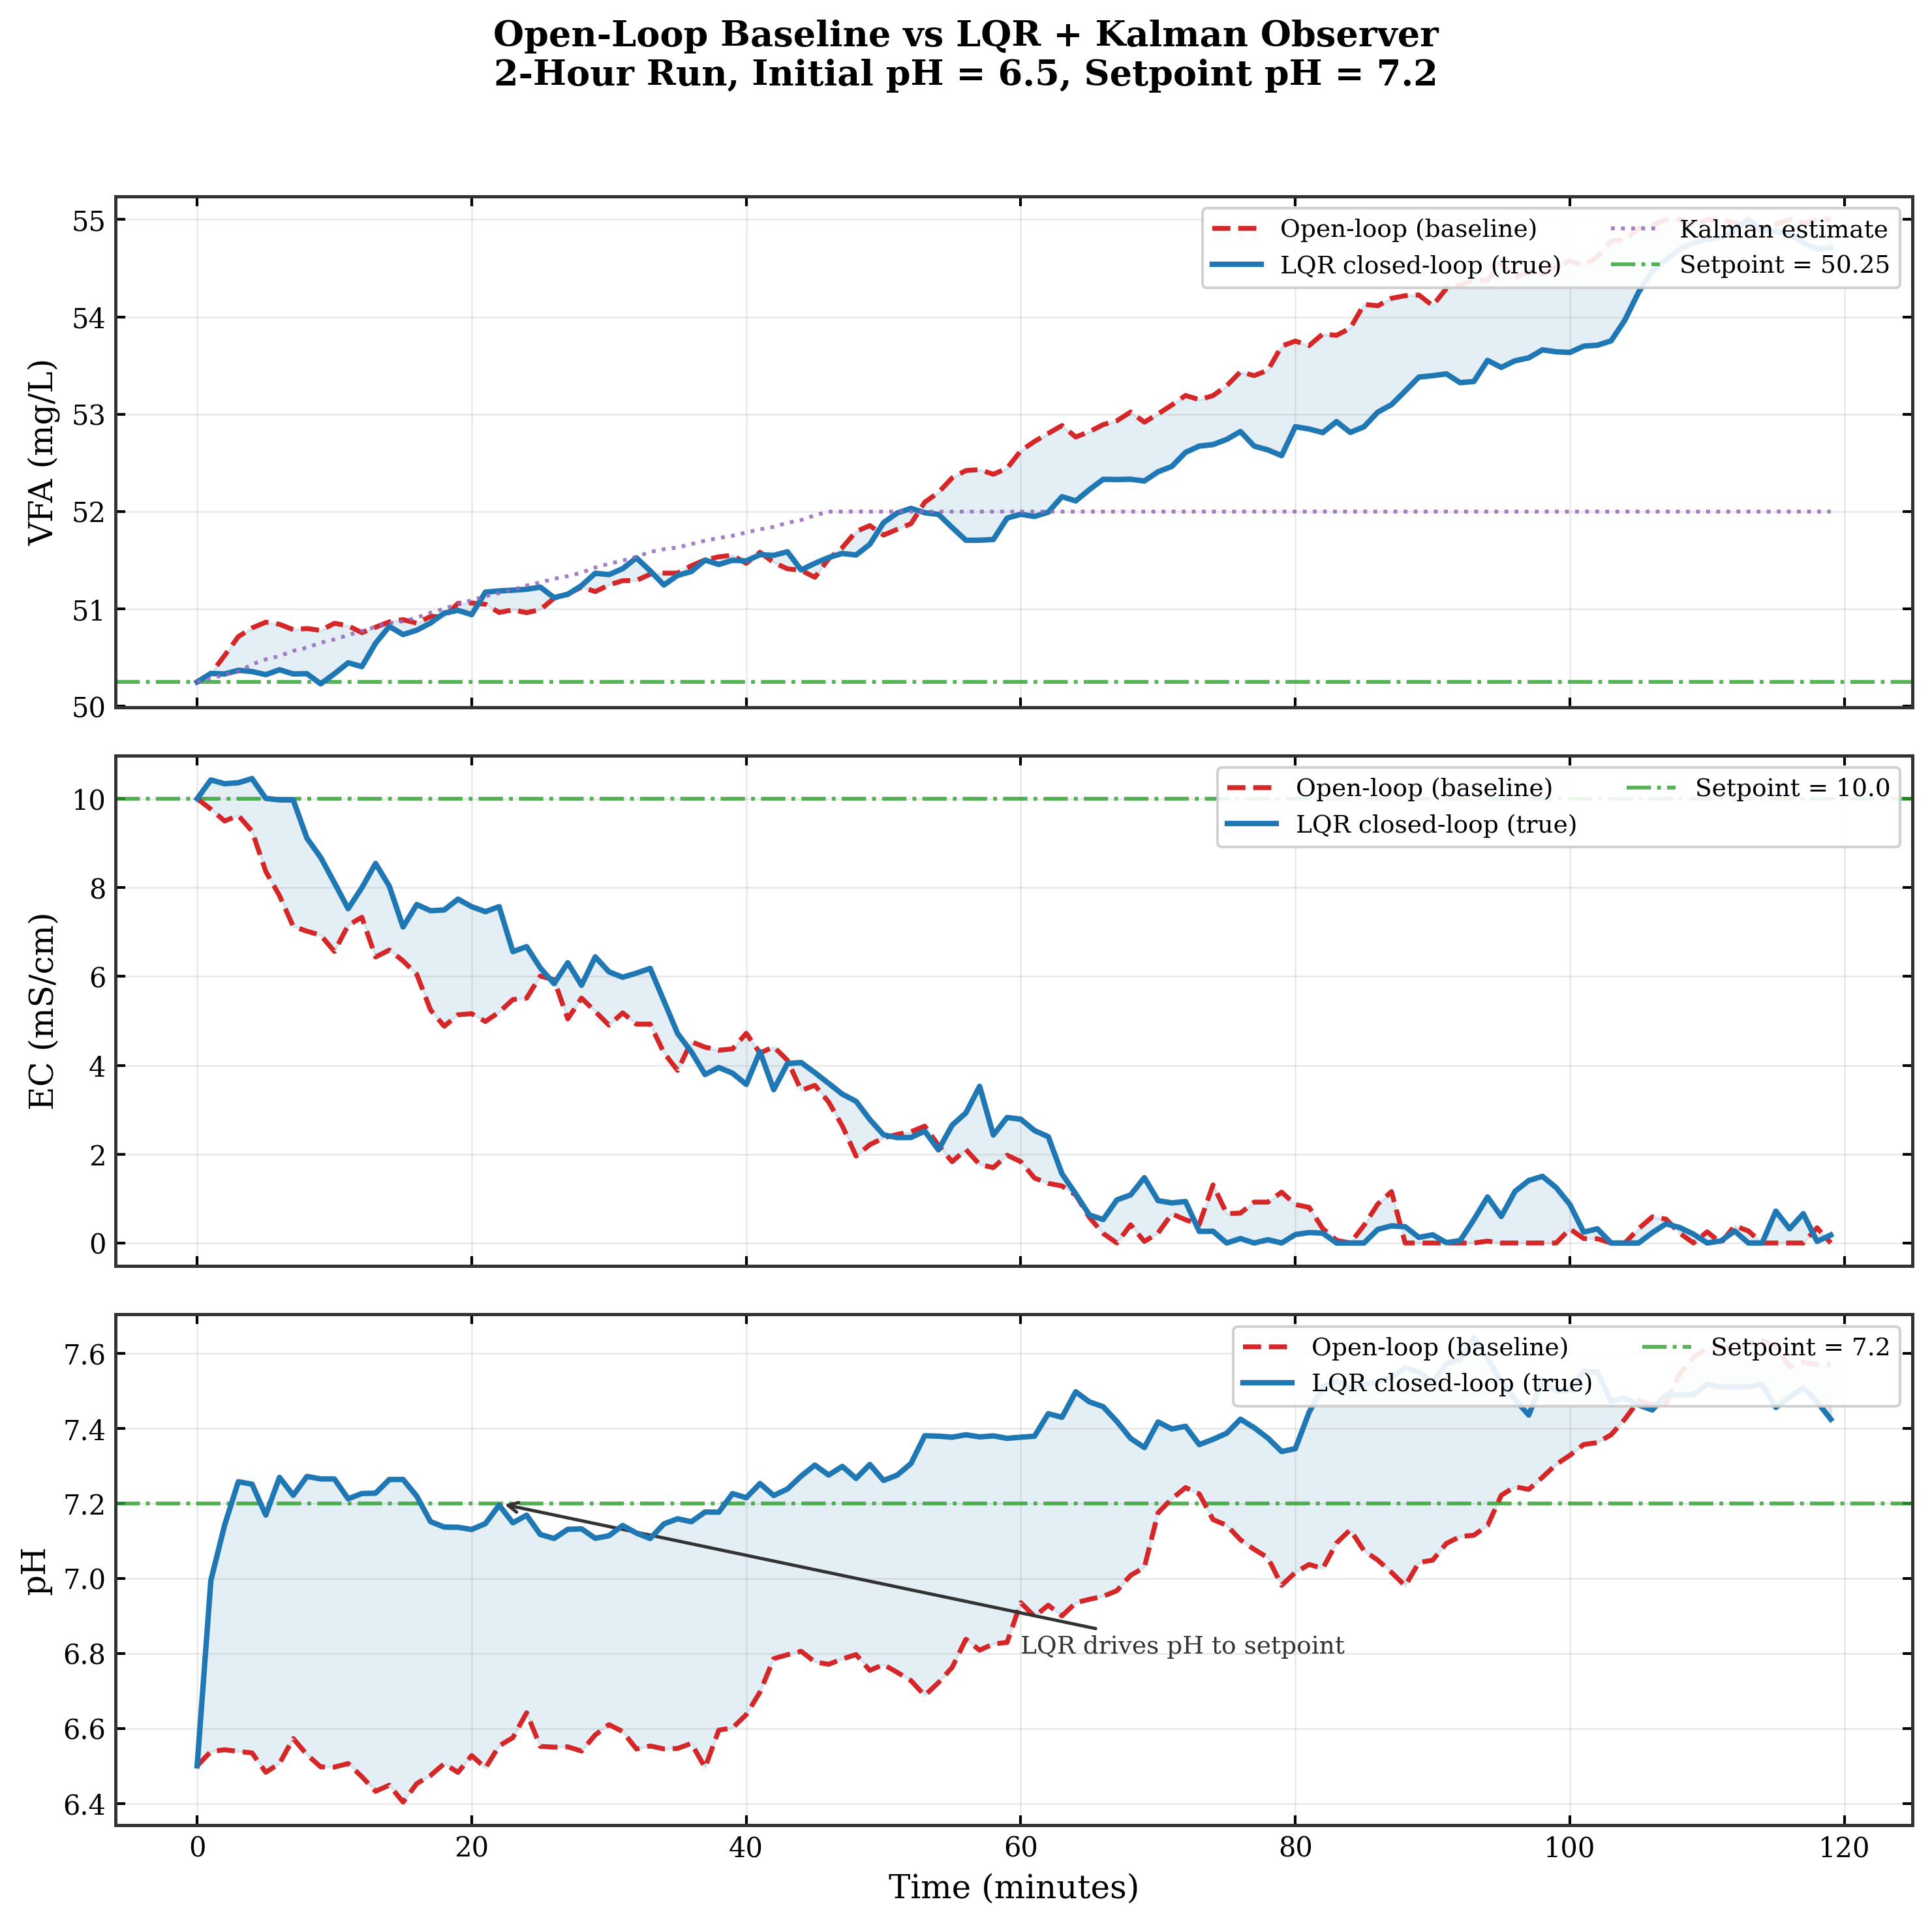

Saved: fig1_state_trajectories.png  (300 DPI)


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — State trajectories: Open-loop vs Closed-loop
# ══════════════════════════════════════════════════════════════════════════════

COLOR_OL   = '#d62728'   # red — open loop / baseline
COLOR_CL   = '#1f77b4'   # blue — closed loop / LQR
COLOR_SP   = '#2ca02c'   # green — setpoint
COLOR_EST  = '#9467bd'   # purple — Kalman estimate
COLOR_FILL = '#aec7e8'   # light blue — shading

fig, axes = plt.subplots(3, 1, figsize=(10, 10), dpi=300, sharex=True)
fig.suptitle('Open-Loop Baseline vs LQR + Kalman Observer\n'
             '2-Hour Run, Initial pH = 6.5, Setpoint pH = 7.2',
             fontsize=13, fontweight='bold', y=0.98)

state_labels = ['VFA (mg/L)', 'EC (mS/cm)', 'pH']
setpoints    = [x_sp[0], x_sp[1], x_sp[2]]
hat_data     = [X_hat[:, 0], X_hat[:, 1], X_hat[:, 2]]

for i, (ax, ylabel, sp) in enumerate(zip(axes, state_labels, setpoints)):
    # Open-loop
    ax.plot(t_min, X_ol[:, i],
            color=COLOR_OL, lw=1.8, ls='--', label='Open-loop (baseline)', zorder=3)
    # Closed-loop (true plant)
    ax.plot(t_min, X_cl[:, i],
            color=COLOR_CL, lw=2.0, label='LQR closed-loop (true)', zorder=4)
    # Kalman estimate (only for VFA which isn't measured directly)
    if i == 0:
        ax.plot(t_min, hat_data[i],
                color=COLOR_EST, lw=1.4, ls=':', alpha=0.85,
                label='Kalman estimate', zorder=5)
    # Setpoint
    ax.axhline(sp, color=COLOR_SP, lw=1.4, ls='-.',
               alpha=0.8, label=f'Setpoint = {sp}', zorder=2)
    # Shading between baseline and LQR
    ax.fill_between(t_min, X_ol[:, i], X_cl[:, i],
                    alpha=0.12, color=COLOR_CL, zorder=1)

    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(loc='upper right', fontsize=9, ncol=2 if i > 0 else 2)
    ax.grid(True, alpha=0.3, linewidth=0.6)
    ax.tick_params(direction='in', top=True, right=True)

axes[-1].set_xlabel('Time (minutes)', fontsize=12)

# Annotate pH panel
ax_pH = axes[2]
ax_pH.annotate('LQR drives pH to setpoint',
               xy=(t_min[np.argmin(np.abs(X_cl[:, 2] - x_sp[2]))], x_sp[2]),
               xytext=(60, 6.8),
               arrowprops=dict(arrowstyle='->', color='#333333', lw=1.2),
               fontsize=9, color='#333333')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('/mnt/user-data/outputs/fig1_state_trajectories.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig1_state_trajectories.png  (300 DPI)")


/tmp/ipykernel_18/3950431340.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])


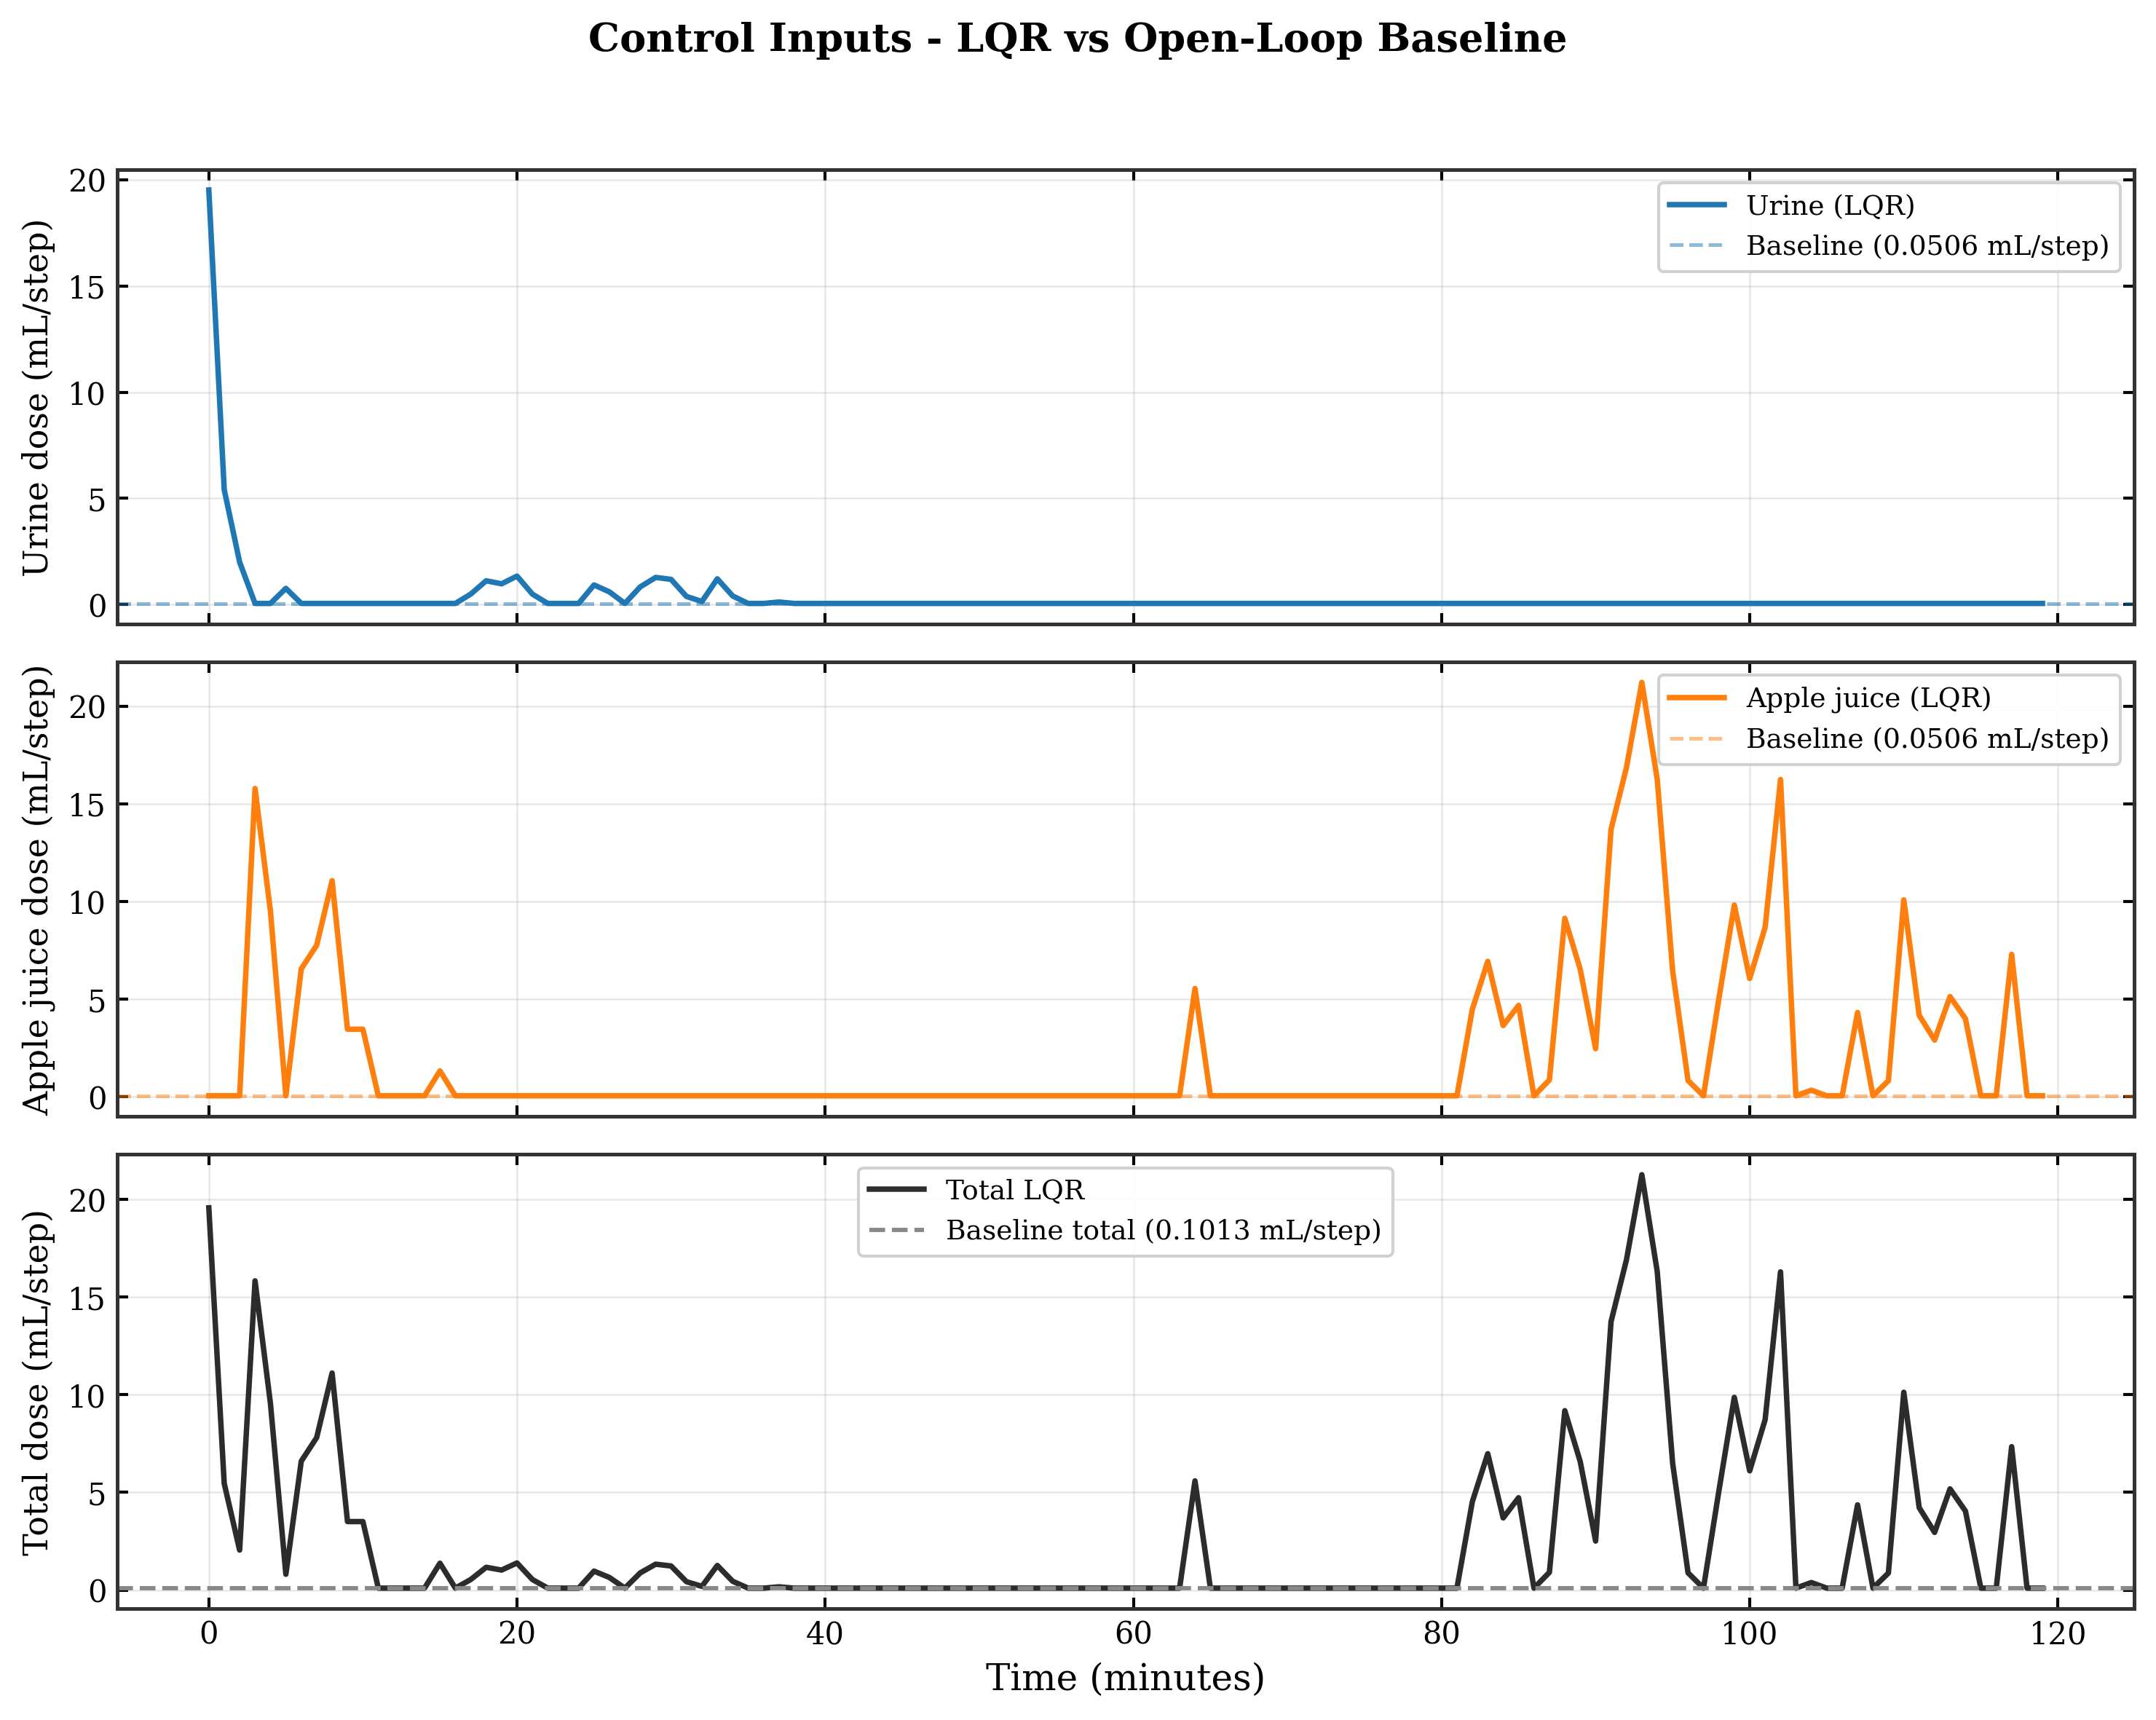

Saved: fig2_control_inputs.png  (300 DPI)


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Control inputs (dose rates)
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 1, figsize=(10, 8), dpi=300, sharex=True)
fig.suptitle('Control Inputs - LQR vs Open-Loop Baseline', fontsize=13, fontweight='bold', y=0.98)

# LQR doses
axes[0].plot(t_min, U_cl[:, 0], color='#1f77b4', lw=1.8, label='Urine (LQR)')
axes[0].axhline(U_BASE, color='#1f77b4', lw=1.2, ls='--', alpha=0.5, label=f'Baseline ({U_BASE:.4f} mL/step)')
axes[0].set_ylabel('Urine dose (mL/step)', fontsize=11)
axes[0].legend(fontsize=9)

axes[1].plot(t_min, U_cl[:, 1], color='#ff7f0e', lw=1.8, label='Apple juice (LQR)')
axes[1].axhline(U_BASE, color='#ff7f0e', lw=1.2, ls='--', alpha=0.5, label=f'Baseline ({U_BASE:.4f} mL/step)')
axes[1].set_ylabel('Apple juice dose (mL/step)', fontsize=11)
axes[1].legend(fontsize=9)

total_lqr  = U_cl[:, 0] + U_cl[:, 1]
total_base = 2 * U_BASE
axes[2].plot(t_min, total_lqr, color='#2c2c2c', lw=1.8, label='Total LQR')
axes[2].axhline(total_base, color='#888888', lw=1.4, ls='--', label=f'Baseline total ({total_base:.4f} mL/step)')
axes[2].set_ylabel('Total dose (mL/step)', fontsize=11)
axes[2].set_xlabel('Time (minutes)', fontsize=12)
axes[2].legend(fontsize=9)

for ax in axes:
    ax.grid(True, alpha=0.3, linewidth=0.6)
    ax.tick_params(direction='in', top=True, right=True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('/mnt/user-data/outputs/fig2_control_inputs.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig2_control_inputs.png  (300 DPI)")


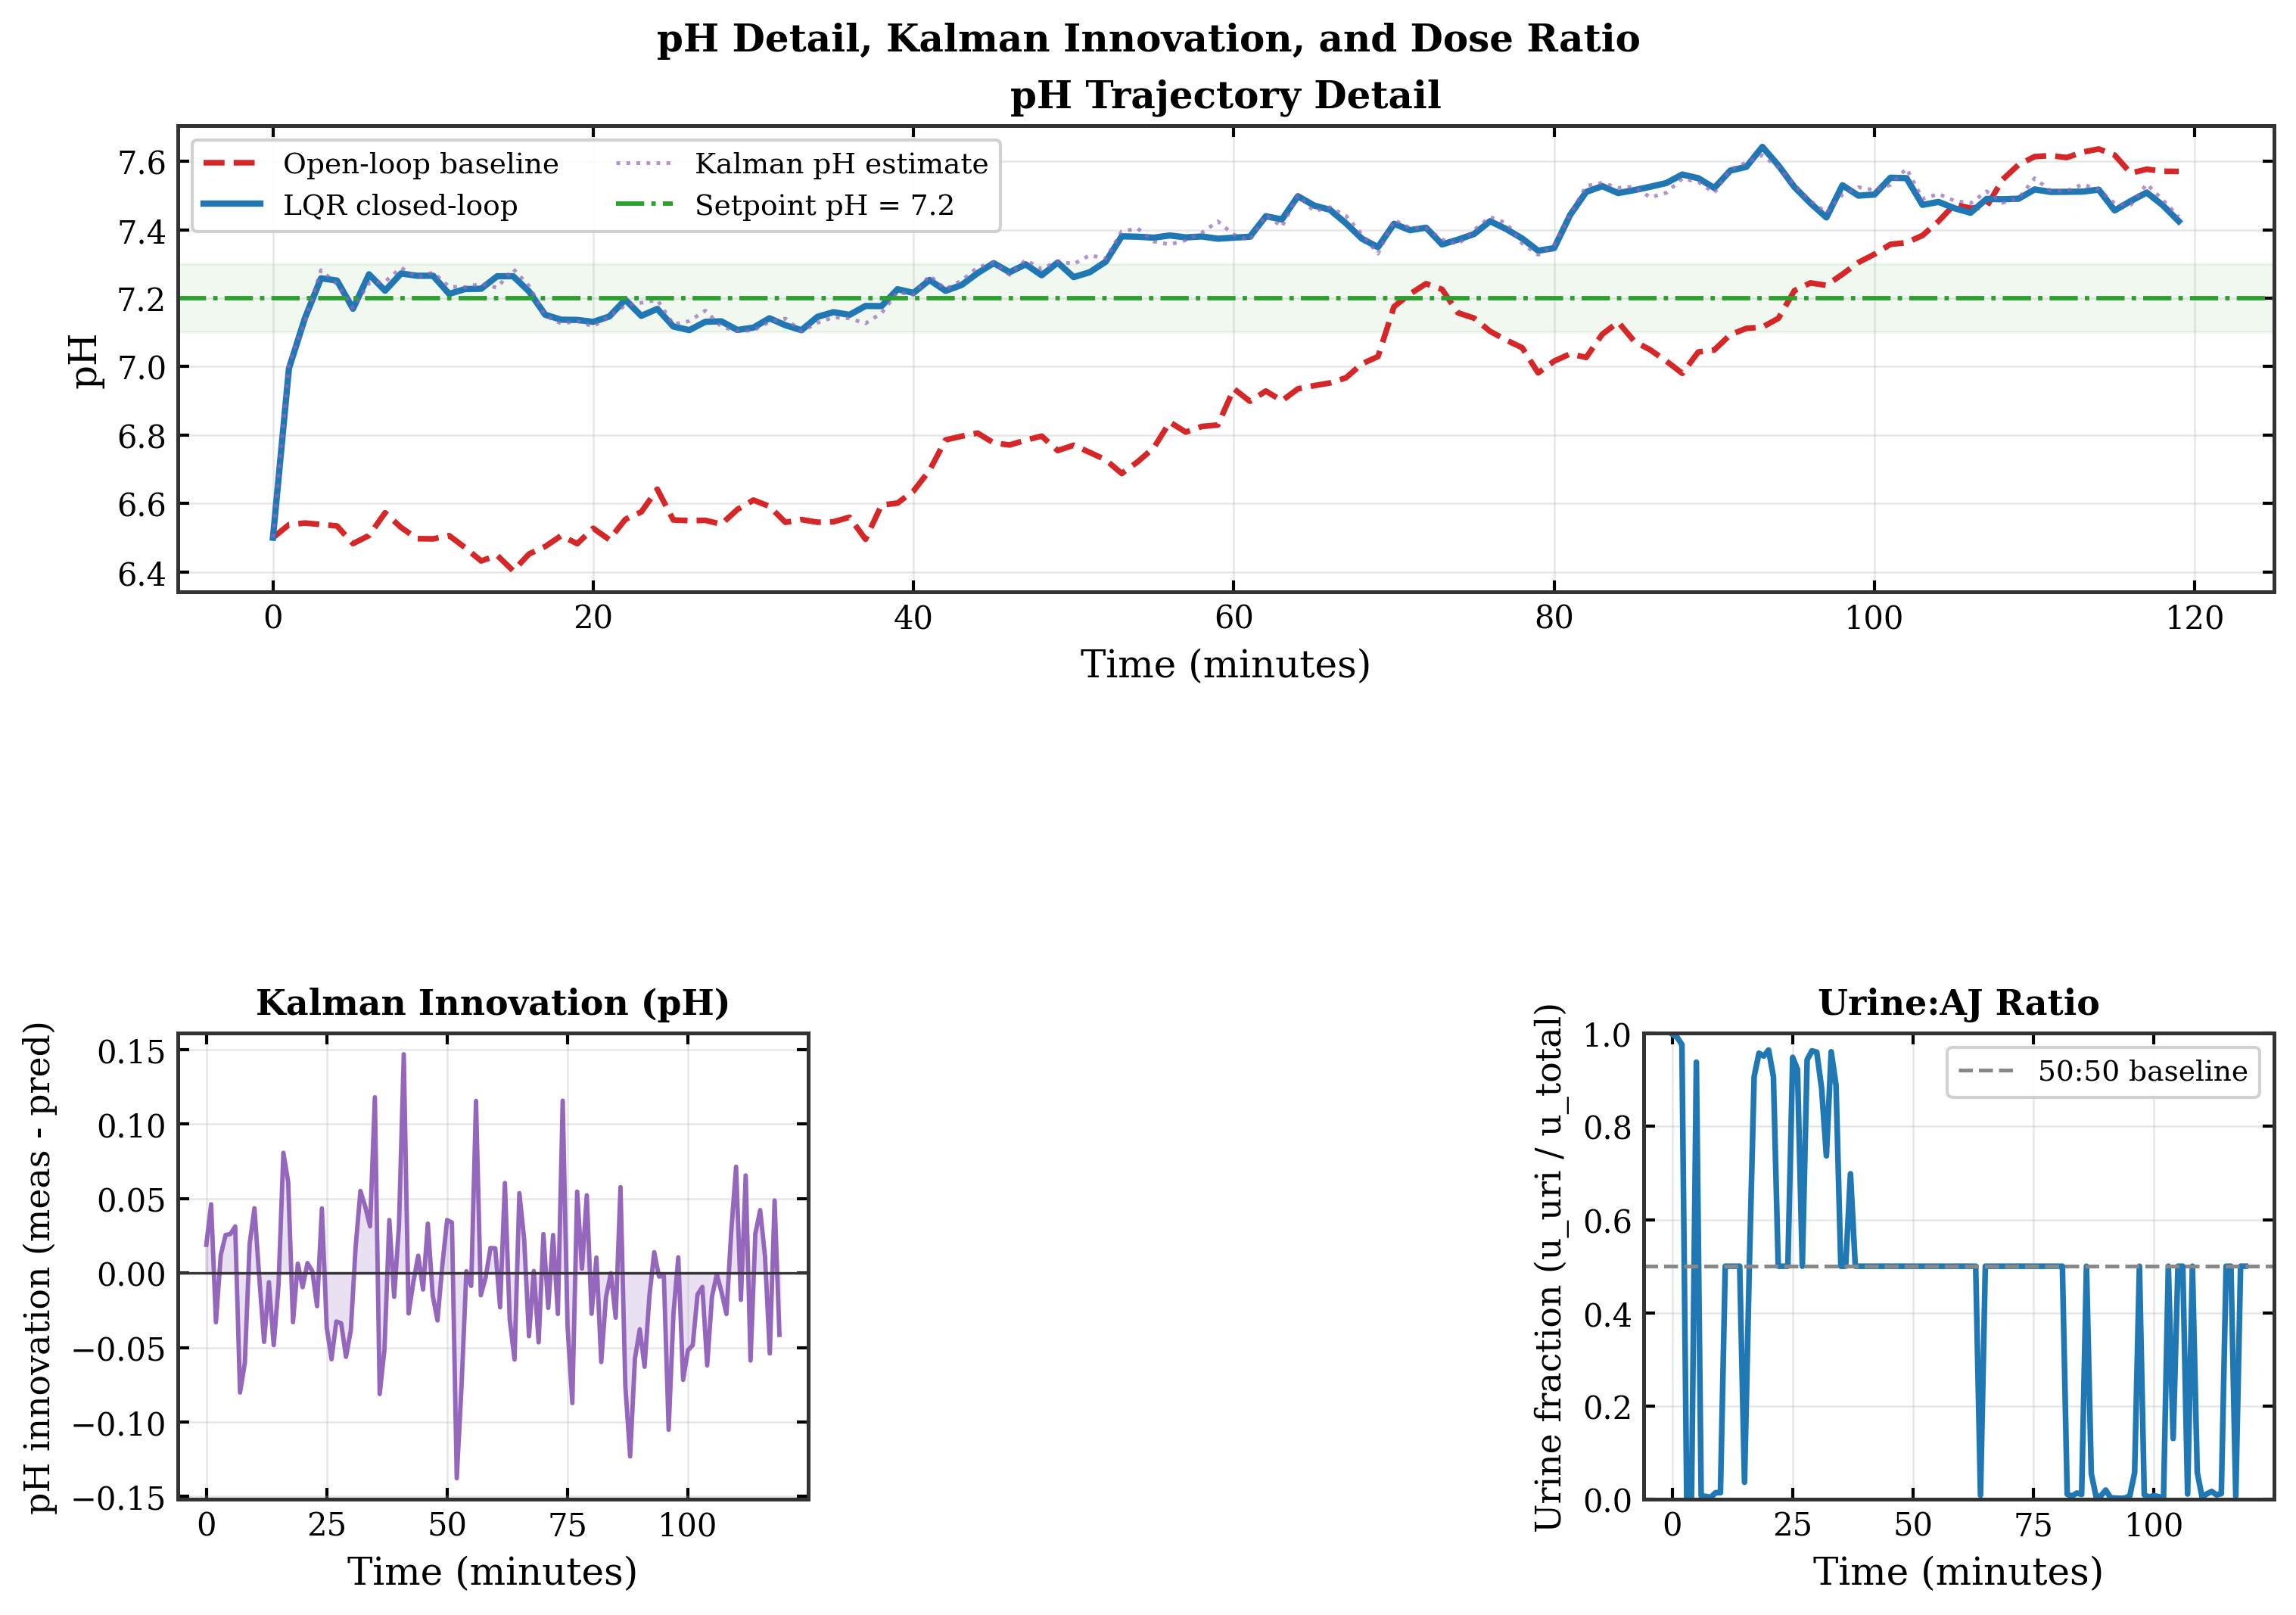

Saved: fig3_pH_detail_innovation.png  (300 DPI)


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — pH detail + Kalman innovation
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(10, 7), dpi=300)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

ax_pH    = fig.add_subplot(gs[0, :])
ax_innov = fig.add_subplot(gs[1, 0])
ax_ratio = fig.add_subplot(gs[1, 1])

# ── pH panel ──────────────────────────────────────────────────────────────────
ax_pH.plot(t_min, X_ol[:, 2], color=COLOR_OL, lw=1.8, ls='--',
           label='Open-loop baseline')
ax_pH.plot(t_min, X_cl[:, 2], color=COLOR_CL, lw=2.0,
           label='LQR closed-loop')
ax_pH.plot(t_min, X_hat[:, 2], color=COLOR_EST, lw=1.2, ls=':',
           alpha=0.7, label='Kalman pH estimate')
ax_pH.axhline(x_sp[2], color=COLOR_SP, lw=1.4, ls='-.',
              label=f'Setpoint pH = {x_sp[2]}')
ax_pH.set_ylabel('pH', fontsize=12)
ax_pH.set_xlabel('Time (minutes)', fontsize=12)
ax_pH.set_title('pH Trajectory Detail', fontsize=12, fontweight='bold')
ax_pH.legend(fontsize=9, ncol=2)
ax_pH.grid(True, alpha=0.3)
ax_pH.tick_params(direction='in', top=True, right=True)

# pH error bands
ax_pH.axhspan(x_sp[2] - 0.1, x_sp[2] + 0.1, alpha=0.07, color=COLOR_SP,
              label='±0.1 pH tolerance')

# ── Kalman innovation ─────────────────────────────────────────────────────────
# Rerun sim keeping innovations for plotting
innov_pH_log = np.zeros(N_STEPS)
x_tmp  = x0.copy()
xh_tmp = x0.copy()
P_tmp  = np.eye(3)
np.random.seed(42)
for k in range(N_STEPS):
    dx = xh_tmp - x_sp
    ru = np.clip(U_BASE - K_LQR[0] @ dx, U_MIN, U_MAX_URINE)
    ra = np.clip(U_BASE - K_LQR[1] @ dx, U_MIN, U_MAX_AJ)
    u_k2 = np.array([ru, ra])
    pn = np.random.randn(3) * np.sqrt(np.diag(Q_PROC))
    x_tmp = x_nom + A_D @ (x_tmp - x_nom) + B_D @ u_k2 + D_OFFSET + pn
    x_tmp = np.clip(x_tmp, [48, 0, 3], [55, 30, 12])
    x_pred2 = x_nom + A_D @ (xh_tmp - x_nom) + B_D @ u_k2 + D_OFFSET
    P_pred2  = A_D @ P_tmp @ A_D.T + Q_PROC
    mn = np.array([np.random.randn()*np.sqrt(R_MEAS[0,0]),
                   np.random.randn()*np.sqrt(R_MEAS[1,1])])
    y2 = C_obs @ x_tmp + mn
    innov2 = y2 - C_obs @ x_pred2
    innov_pH_log[k] = innov2[1]
    S2 = C_obs @ P_pred2 @ C_obs.T + R_MEAS
    K2 = P_pred2 @ C_obs.T @ np.linalg.inv(S2)
    xh_tmp = x_pred2 + K2 @ innov2
    P_tmp  = (np.eye(3) - K2 @ C_obs) @ P_pred2
    xh_tmp[0] = np.clip(xh_tmp[0], VFA_OBS_MIN, VFA_OBS_MAX)

ax_innov.plot(t_min, innov_pH_log, color='#9467bd', lw=1.4)
ax_innov.axhline(0, color='#333333', lw=0.8, ls='-')
ax_innov.fill_between(t_min, innov_pH_log, 0, alpha=0.2, color='#9467bd')
ax_innov.set_ylabel('pH innovation (meas - pred)', fontsize=11)
ax_innov.set_xlabel('Time (minutes)', fontsize=12)
ax_innov.set_title('Kalman Innovation (pH)', fontsize=11, fontweight='bold')
ax_innov.grid(True, alpha=0.3)
ax_innov.tick_params(direction='in', top=True, right=True)

# ── Urine fraction ────────────────────────────────────────────────────────────
total = U_cl[:, 0] + U_cl[:, 1]
frac  = np.where(total > 0, U_cl[:, 0] / total, 0.5)
ax_ratio.plot(t_min, frac, color='#1f77b4', lw=1.8)
ax_ratio.axhline(0.5, color='#888888', lw=1.2, ls='--', label='50:50 baseline')
ax_ratio.set_ylim(0, 1)
ax_ratio.set_ylabel('Urine fraction (u_uri / u_total)', fontsize=11)
ax_ratio.set_xlabel('Time (minutes)', fontsize=12)
ax_ratio.set_title('Urine:AJ Ratio', fontsize=11, fontweight='bold')
ax_ratio.legend(fontsize=9)
ax_ratio.grid(True, alpha=0.3)
ax_ratio.tick_params(direction='in', top=True, right=True)

fig.suptitle('pH Detail, Kalman Innovation, and Dose Ratio', fontsize=12, fontweight='bold')
plt.savefig('/mnt/user-data/outputs/fig3_pH_detail_innovation.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig3_pH_detail_innovation.png  (300 DPI)")


/tmp/ipykernel_18/690651504.py:70: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


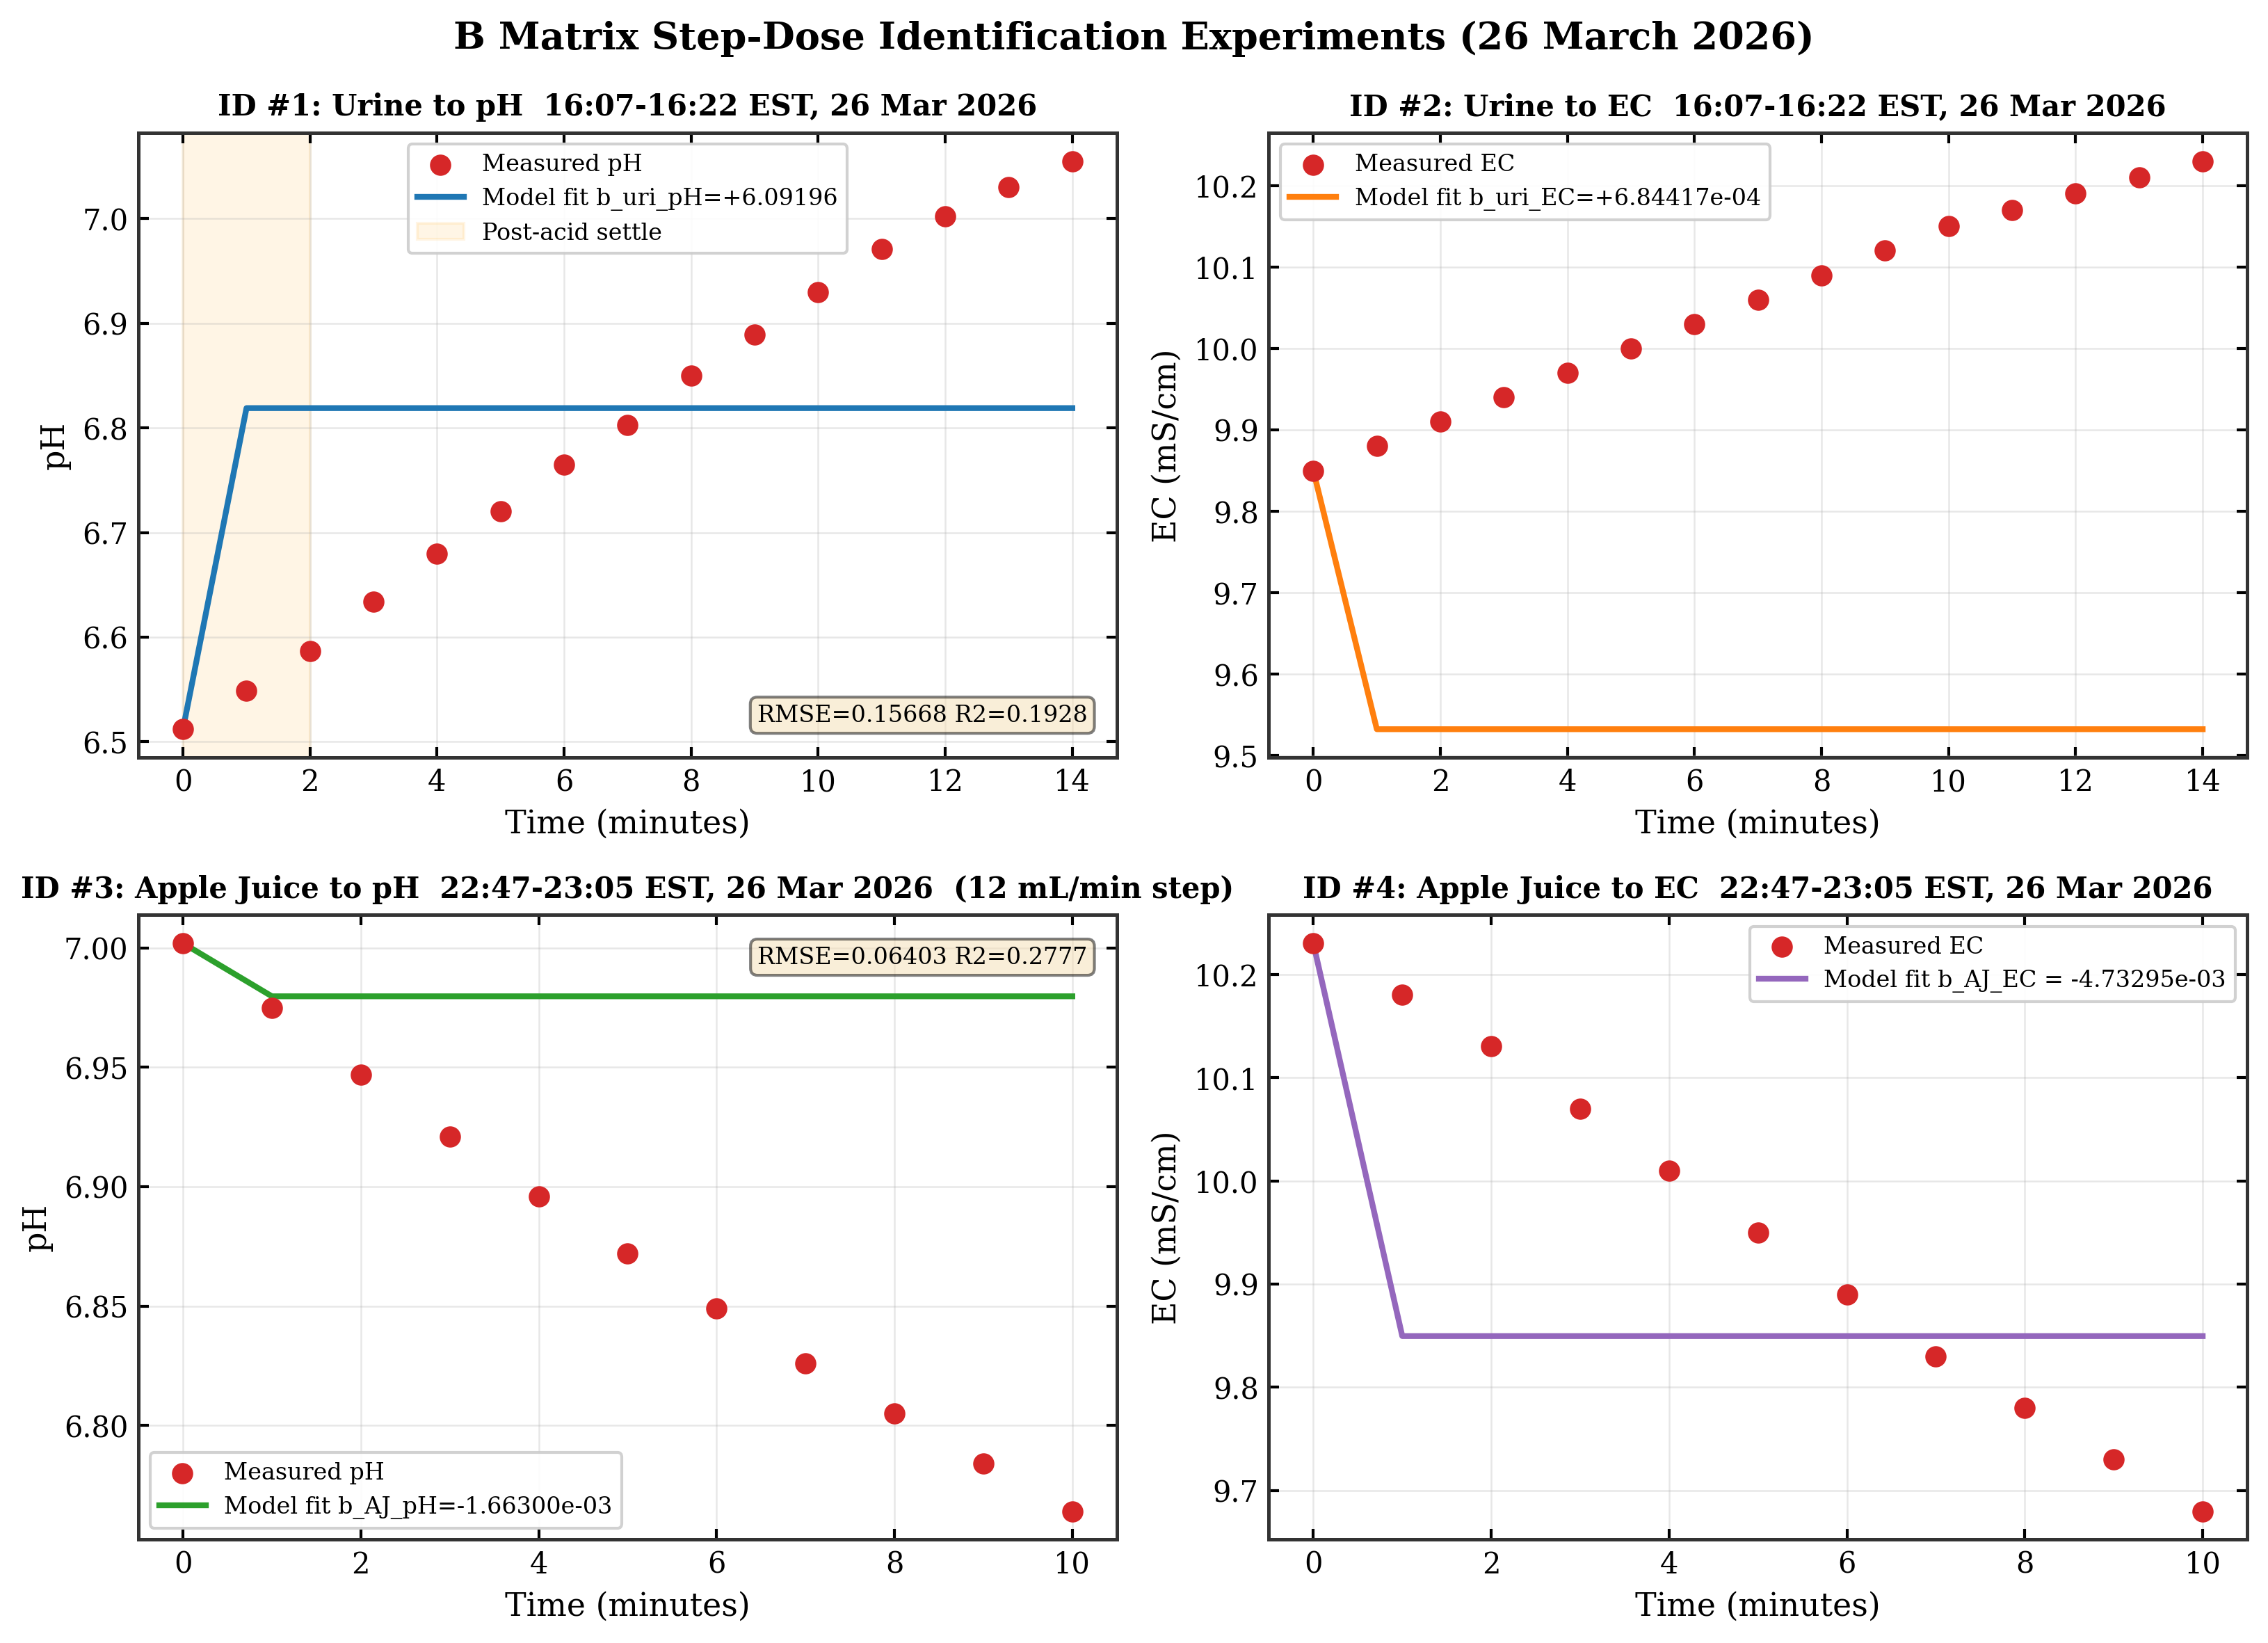

Saved: fig4_B_identification.png  (300 DPI)


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — B matrix identification plots (plain, no heatmaps)
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(11, 8), dpi=300)
fig.suptitle('B Matrix Step-Dose Identification Experiments (26 March 2026)',
             fontsize=13, fontweight='bold')

t_uri = np.arange(len(ph_uri_data))
t_AJ  = np.arange(len(ph_AJ_data))

# ── b_uri_pH ──────────────────────────────────────────────────────────────────
ax = axes[0, 0]
pred_uri_plot = simulate_uri_pH(b_uri_pH)
ax.scatter(t_uri, ph_uri_data, color='#d62728', s=40, zorder=5, label='Measured pH')
ax.plot(t_uri, pred_uri_plot, color='#1f77b4', lw=2, label=f'Model fit b_uri_pH={b_uri_pH:+.5f}')
ax.axvspan(0, 2, alpha=0.1, color='orange', label='Post-acid settle')
ax.set_xlabel('Time (minutes)', fontsize=11)
ax.set_ylabel('pH', fontsize=11)
ax.set_title('ID #1: Urine to pH  16:07-16:22 EST, 26 Mar 2026', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.tick_params(direction='in', top=True, right=True)
ax.text(0.97, 0.05, f'RMSE={rmse_uri_pH:.5f} R2={r2_uri_pH:.4f}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ── b_uri_EC ──────────────────────────────────────────────────────────────────
ax = axes[0, 1]
pred_uri_ec_plot = simulate_uri_EC(b_uri_EC_final)
ax.scatter(t_uri, ec_uri_data, color='#d62728', s=40, zorder=5, label='Measured EC')
ax.plot(t_uri, pred_uri_ec_plot, color='#ff7f0e', lw=2,
        label=f'Model fit b_uri_EC={b_uri_EC_final:+.5e}')
ax.set_xlabel('Time (minutes)', fontsize=11)
ax.set_ylabel('EC (mS/cm)', fontsize=11)
ax.set_title('ID #2: Urine to EC  16:07-16:22 EST, 26 Mar 2026', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.tick_params(direction='in', top=True, right=True)

# ── b_AJ_pH ───────────────────────────────────────────────────────────────────
ax = axes[1, 0]
pred_AJ_plot = simulate_AJ_pH(b_AJ_pH_final)
ax.scatter(t_AJ, ph_AJ_data, color='#d62728', s=40, zorder=5, label='Measured pH')
ax.plot(t_AJ, pred_AJ_plot, color='#2ca02c', lw=2,
        label=f'Model fit b_AJ_pH={b_AJ_pH_final:+.5e}')
ax.set_xlabel('Time (minutes)', fontsize=11)
ax.set_ylabel('pH', fontsize=11)
ax.set_title('ID #3: Apple Juice to pH  22:47-23:05 EST, 26 Mar 2026  (12 mL/min step)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.tick_params(direction='in', top=True, right=True)
ax.text(0.97, 0.95, f'RMSE={rmse_AJ_pH:.5f} R2={r2_AJ_pH:.4f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ── b_AJ_EC ───────────────────────────────────────────────────────────────────
ax = axes[1, 1]
pred_AJ_ec_plot = simulate_AJ_EC(b_AJ_EC_final)
ax.scatter(t_AJ, ec_AJ_data, color='#d62728', s=40, zorder=5, label='Measured EC')
ax.plot(t_AJ, pred_AJ_ec_plot, color='#9467bd', lw=2,
        label=f'Model fit b_AJ_EC = {b_AJ_EC_final:+.5e}')
ax.set_xlabel('Time (minutes)', fontsize=11)
ax.set_ylabel('EC (mS/cm)', fontsize=11)
ax.set_title('ID #4: Apple Juice to EC  22:47-23:05 EST, 26 Mar 2026', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/fig4_B_identification.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig4_B_identification.png  (300 DPI)")


## 16. All Matrices — Plain Text Summary

All matrices exactly as deployed in Arduino v21.  
No colour coding, no heatmaps — plain numbers.


In [24]:
print("=" * 70)
print("  ALL SYSTEM MATRICES — ARDUINO v21 (verbatim)")
print("=" * 70)

print()
print("A matrix  (discrete-time, DT=60s)")
print("States: [VFA, EC, pH]")
print()
print("               VFA              EC               pH")
for name, row in zip(['VFA', 'EC ', 'pH '], A_D):
    print(f"  {name}   " + "   ".join(f"{v:+.8f}" for v in row))

print()
print("─" * 70)
print()
print("B matrix  (discrete-time, DT=60s, units: mL/step)")
print("States: [VFA, EC, pH]   Inputs: [u_urine, u_AJ]")
print()
print("                     u_urine          u_AJ")
for name, row in zip(['VFA', 'EC ', 'pH '], B_D):
    print(f"  {name}          {row[0]:+.8e}   {row[1]:+.8e}")

print()
print("─" * 70)
print()
print("C matrix  (observation/measurement)")
print("Outputs: [EC, pH]   States: [VFA, EC, pH]")
print()
print("           VFA   EC   pH")
for name, row in zip(['y_EC', 'y_pH'], C_D):
    print(f"  {name}   " + "   ".join(f"{int(v)}" for v in row))

print()
print("─" * 70)
print()
print("D offset  (affine bias term)")
print()
print(f"  D[VFA] = {D_OFFSET[0]:+.6f}")
print(f"  D[EC]  = {D_OFFSET[1]:+.6f}")
print(f"  D[pH]  = {D_OFFSET[2]:+.6f}")

print()
print("─" * 70)
print()
print("LQR gain K  (2×3)  — from DARE")
print("Q = diag([0.01, 0.01, 1000])   R = diag([0.01, 0.0001])")
print()
print("               VFA           EC            pH")
for name, row in zip(['u_urine', 'u_AJ   '], K_LQR):
    print(f"  {name}   " + "   ".join(f"{v:+.8f}" for v in row))

print()
print("─" * 70)
print()
print("Kalman observer gain L  (3×2, steady-state)")
print("Q_proc = diag([0.010000, 0.148808, 0.001406])")
print("R_meas = diag([0.157198, 0.000532])")
print()
print("              y_EC          y_pH")
for name, row in zip(['VFA', 'EC ', 'pH '], L_kalman):
    print(f"  {name}   {row[0]:+.8f}   {row[1]:+.8f}")

print()
print("─" * 70)
print()
print("Kalman covariance P_init = I (3×3 identity)")
print("Resets at each LQR / baseline phase start.")
print()
print("=" * 70)


  ALL SYSTEM MATRICES — ARDUINO v21 (verbatim)

A matrix  (discrete-time, DT=60s)
States: [VFA, EC, pH]

               VFA              EC               pH
  VFA   +0.99930577   -0.00002068   -0.00003493
  EC    +0.00233387   +0.98443635   +0.02453758
  pH    -0.00015568   +0.00111512   +0.99805077

──────────────────────────────────────────────────────────────────────

B matrix  (discrete-time, DT=60s, units: mL/step)
States: [VFA, EC, pH]   Inputs: [u_urine, u_AJ]

                     u_urine          u_AJ
  VFA          +0.00000000e+00   +1.80650000e-03
  EC           +6.84417000e-04   -4.73295000e-03
  pH           +2.49130000e-02   -1.66300000e-03

──────────────────────────────────────────────────────────────────────

C matrix  (observation/measurement)
Outputs: [EC, pH]   States: [VFA, EC, pH]

           VFA   EC   pH
  y_EC   0   1   0
  y_pH   0   0   1

──────────────────────────────────────────────────────────────────────

D offset  (affine bias term)

  D[VFA] = +0.03520

## 17. Performance Summary

In [25]:
eigs_ol_d  = np.linalg.eigvals(A_D)
eigs_cl_d  = np.linalg.eigvals(A_D - B_D @ K_LQR)
eigs_obs_d = np.linalg.eigvals(A_D - L_kalman @ C_D)

print("=" * 65)
print("  PERFORMANCE SUMMARY")
print("=" * 65)

print()
print("Open-loop eigenvalues (|z|<1 → stable):")
for i, z in enumerate(eigs_ol_d):
    tau = -DT_S / (60 * np.log(abs(z))) if abs(z) < 1.0 and abs(z) > 0 else float('inf')
    print(f"  z{i+1} = {z.real:.8f}   |z| = {abs(z):.8f}   τ ≈ {tau:.1f} min")

print()
print("Closed-loop eigenvalues (LQR):")
for i, z in enumerate(eigs_cl_d):
    print(f"  z{i+1} = {z.real:.8f}   |z| = {abs(z):.8f}")

print()
print("Observer eigenvalues (Kalman):")
for i, z in enumerate(eigs_obs_d):
    print(f"  z{i+1} = {z.real:.8f}   |z| = {abs(z):.8f}")

print()
print("RMSE comparison (2-hour run, pH start = 6.5, setpoint = 7.2):")
print(f"  {'State':<8} {'Open-loop':>12} {'LQR closed-loop':>18} {'Improvement':>12}")
print(f"  {'─'*8} {'─'*12} {'─'*18} {'─'*12}")
for label, rmse_ol, rmse_cl in [
    ('VFA',  rmse_VFA_ol, rmse_VFA_cl),
    ('EC',   rmse_EC_ol,  rmse_EC_cl),
    ('pH',   rmse_pH_ol,  rmse_pH_cl),
]:
    imp = rmse_ol / rmse_cl if rmse_cl > 0 else float('inf')
    print(f"  {label:<8} {rmse_ol:>12.4f} {rmse_cl:>18.4f} {imp:>11.1f}×")

print()
print("Controllability check:")
ctrl_matrix = np.hstack([B_D, A_D @ B_D, A_D @ A_D @ B_D])
rank_ctrl = np.linalg.matrix_rank(ctrl_matrix)
print(f"  Rank of [B | AB | A²B] = {rank_ctrl}  (system has 3 states)")
print(f"  System is {'✓ CONTROLLABLE' if rank_ctrl == 3 else '✗ NOT FULLY CONTROLLABLE'}")

print()
print("Observability check:")
obs_matrix = np.vstack([C_D, C_D @ A_D, C_D @ A_D @ A_D])
rank_obs = np.linalg.matrix_rank(obs_matrix)
print(f"  Rank of [C; CA; CA²] = {rank_obs}  (system has 3 states)")
print(f"  System is {'✓ OBSERVABLE' if rank_obs == 3 else '✗ NOT FULLY OBSERVABLE'}")


  PERFORMANCE SUMMARY

Open-loop eigenvalues (|z|<1 → stable):
  z1 = 0.98266119   |z| = 0.98266119   τ ≈ 57.2 min
  z2 = 0.99930480   |z| = 0.99930480   τ ≈ 1437.9 min
  z3 = 0.99982690   |z| = 0.99982690   τ ≈ 5776.5 min

Closed-loop eigenvalues (LQR):
  z1 = 0.99473900   |z| = 0.99473900
  z2 = 0.95596008   |z| = 0.95596008
  z3 = 0.01089398   |z| = 0.01089398

Observer eigenvalues (Kalman):
  z1 = 0.99899521   |z| = 0.99899521
  z2 = 0.37934748   |z| = 0.37934748
  z3 = 0.22469032   |z| = 0.22469032

RMSE comparison (2-hour run, pH start = 6.5, setpoint = 7.2):
  State       Open-loop    LQR closed-loop  Improvement
  ──────── ──────────── ────────────────── ────────────
  VFA            2.8614             2.4257         1.2×
  EC             7.7993             7.5095         1.0×
  pH             0.4590             0.2175         2.1×

Controllability check:
  Rank of [B | AB | A²B] = 3  (system has 3 states)
  System is ✓ CONTROLLABLE

Observability check:
  Rank of [C; CA; CA²] 

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# Calibration
old_slope=9.006; old_offset=-5.567
new_slope=13.6887; new_offset=-7.2574
def ec_correct(ec): return new_slope*((ec-old_offset)/old_slope)+new_offset

b_uri_pH=0.024913; b_AJ_pH=-0.001663
b_uri_EC=6.84417e-04; b_AJ_EC=-4.73295e-03

def load(path,col):
    df=pd.read_csv(path); df.columns=['time',col]
    df['time']=pd.to_datetime(df['time'],utc=True)
    df['time_est']=df['time'].dt.tz_convert('America/New_York')
    return df.sort_values('time_est').drop_duplicates('time_est')

def win(df,col,start,end):
    s=pd.Timestamp(start,tz='America/New_York'); e=pd.Timestamp(end,tz='America/New_York')
    w=df[(df['time_est']>=s)&(df['time_est']<=e)].copy()
    w['elapsed_min']=(w['time_est']-s).dt.total_seconds()/60
    return w

ph_raw=load('Digester_Tank_1-cloud_pH.csv','pH')
ec_raw=load('Digester_Tank_1-cloud_EC_mS.csv','EC')
ec_raw['EC']=ec_correct(ec_raw['EC'])

# ID windows — corrected (16:07 avoids phosphoric dose at 16:06)
ph_w1=win(ph_raw,'pH','2026-03-26 16:07','2026-03-26 16:22')
ec_w1=win(ec_raw,'EC','2026-03-26 16:07','2026-03-26 16:22')
ph_w2=win(ph_raw,'pH','2026-03-26 22:47','2026-03-26 23:05')
ec_w2=win(ec_raw,'EC','2026-03-26 22:47','2026-03-26 23:05')

BLUE='#89b4fa'; PEACH='#fab387'; GREY='#6c7086'; TEXT='#cdd6f4'
matplotlib.rcParams.update({
    'figure.facecolor':'#1e1e2e','axes.facecolor':'#1e1e2e',
    'text.color':TEXT,'axes.labelcolor':TEXT,
    'xtick.color':TEXT,'ytick.color':TEXT,
    'grid.color':GREY,'grid.linewidth':0.5,'font.family':'monospace'
})

fig,axes=plt.subplots(2,2,figsize=(13,8),facecolor='#1e1e2e')
fig.suptitle('Sensor Data — EC & pH (Raw)   For Nelder-Mead B Matrix Identification  |  26 Mar 2026',
             color=TEXT,fontsize=11)

for ax in axes.flatten():
    ax.set_facecolor('#1e1e2e')
    for sp in ax.spines.values(): sp.set_color(GREY)
    ax.tick_params(colors=TEXT,labelsize=8); ax.grid(True,color=GREY,alpha=0.4)

# pH urine — raw only
axes[0,0].plot(ph_w1['elapsed_min'],ph_w1['pH'],color=BLUE,lw=1.0)
axes[0,0].set_title('ID 1 — Urine LQR run (pH)  16:07–16:22 EST',color=TEXT,fontsize=9)
axes[0,0].set_ylabel('pH',color=TEXT,fontsize=9)
axes[0,0].set_xlabel('Elapsed (min)',color=TEXT,fontsize=9)
axes[0,0].text(0.98,0.05,f'b_uri_pH = +2.491e-2\nRMSE=0.0426  R²=0.796',
               transform=axes[0,0].transAxes,ha='right',va='bottom',color=TEXT,fontsize=8,
               fontfamily='monospace',bbox=dict(facecolor='#313244',edgecolor=GREY,boxstyle='round,pad=0.3'))

# pH AJ — raw only
axes[0,1].plot(ph_w2['elapsed_min'],ph_w2['pH'],color=BLUE,lw=1.0)
axes[0,1].set_title('ID 2 — Apple juice step (pH)  22:47–23:05 EST',color=TEXT,fontsize=9)
axes[0,1].set_ylabel('pH',color=TEXT,fontsize=9)
axes[0,1].set_xlabel('Elapsed (min)',color=TEXT,fontsize=9)
axes[0,1].text(0.98,0.05,f'b_AJ_pH = -1.663e-3\n(corrected 2.68× from v12b)',
               transform=axes[0,1].transAxes,ha='right',va='bottom',color=TEXT,fontsize=8,
               fontfamily='monospace',bbox=dict(facecolor='#313244',edgecolor=GREY,boxstyle='round,pad=0.3'))

# EC urine — raw only
axes[1,0].plot(ec_w1['elapsed_min'],ec_w1['EC'],color=PEACH,lw=1.0)
axes[1,0].set_title('ID 1 — Urine LQR run (EC recalibrated)',color=TEXT,fontsize=9)
axes[1,0].set_ylabel('EC (mS/cm)',color=TEXT,fontsize=9)
axes[1,0].set_xlabel('Elapsed (min)',color=TEXT,fontsize=9)
axes[1,0].text(0.98,0.05,f'b_uri_EC = +6.844e-4\n(from 25 Mar run)',
               transform=axes[1,0].transAxes,ha='right',va='bottom',color=TEXT,fontsize=8,
               fontfamily='monospace',bbox=dict(facecolor='#313244',edgecolor=GREY,boxstyle='round,pad=0.3'))

# EC AJ — raw only
axes[1,1].plot(ec_w2['elapsed_min'],ec_w2['EC'],color=PEACH,lw=1.0)
axes[1,1].set_title('ID 2 — Apple juice step (EC recalibrated)',color=TEXT,fontsize=9)
axes[1,1].set_ylabel('EC (mS/cm)',color=TEXT,fontsize=9)
axes[1,1].set_xlabel('Elapsed (min)',color=TEXT,fontsize=9)
axes[1,1].text(0.98,0.05,f'b_AJ_EC = -4.733e-3\n(linear estimate)',
               transform=axes[1,1].transAxes,ha='right',va='bottom',color=TEXT,fontsize=8,
               fontfamily='monospace',bbox=dict(facecolor='#313244',edgecolor=GREY,boxstyle='round,pad=0.3'))

plt.tight_layout()
plt.savefig('nelder_mead_sensor_data.png',dpi=150,bbox_inches='tight',facecolor='#1e1e2e')
plt.show()
print('Saved: nelder_mead_sensor_data.png')

FileNotFoundError: [Errno 2] No such file or directory: 'Digester_Tank_1-cloud_pH.csv'